# Mouse-Gaze Convergence as a Function of Click Intent

> **Task constraint note:** AdSERP is a forced-click lab study — participants must click a SERP result, with no competing tabs or abandonment option. Mouse X variance is artificially low compared to real browsing where attention splits across the browser chrome. The convergence *mechanism* (mouse approaches gaze target as decision crystallizes) should generalize; the *base rates* (absolute distances, convergence timing) are specific to this constrained task. See [findings caveats](docs/findings.md#caveats).

**Hypothesis:** Academic work on mouse-gaze distance has not conditioned on p(click). The higher the click probability, the closer the mouse should be to the eye — because the mouse must converge on the gaze target to execute the click. Averaging across entire browsing sessions (including scanning/idle periods) inflates the reported divergence.

In [1]:
# Shared data loading — see data_loader.py for all utilities
from data_loader import *
setup_plotting()
import os
import csv
import math
import statistics
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


In [2]:
def load_metadata(trial_id):
    path = os.path.join(METADATA_DIR, f'{trial_id}.xml')
    tree = ET.parse(path)
    root = tree.getroot()
    win = root.find('window').text.split('x')
    return {'win_w': int(win[0]), 'win_h': int(win[1])}

def load_fixations(trial_id):
    path = os.path.join(FIXATION_DIR, f'{trial_id}.csv')
    rows = []
    with open(path) as f:
        for r in csv.DictReader(f):
            rows.append((int(float(r['timestamp'])), int(float(r['FPOGX'])), int(float(r['FPOGY'])), int(float(r['FPOGD']))))
    return rows  # (t, x, y_page_space, dur)

def load_mouse_and_scroll(trial_id, meta):
    """Load mouse moves, click time, and scroll offsets from one file pass."""
    path = os.path.join(MOUSE_DIR, f'{trial_id}.csv')
    rx = 1280 / meta['win_w']
    ry = 1024 / meta['win_h']
    moves = []
    scrolls = []
    click_t = None
    with open(path) as f:
        for r in csv.DictReader(f):
            t = int(float(r['timestamp']))
            if r['event'] == 'click':
                click_t = t
            if r['event'] in ('mousemove', 'mouseover'):
                x = int(float(r['xpos'])) * rx
                y = int(float(r['ypos'])) * ry
                moves.append((t, x, y))
            if r['event'] == 'scroll':
                scrolls.append((t, float(r['ypos'])))
    return moves, click_t, scrolls

def get_scroll_at(t, scrolls):
    """Get cumulative scroll Y offset at time t."""
    if not scrolls:
        return 0.0
    offset = 0.0
    for st, sy in scrolls:
        if st <= t:
            offset = sy
        else:
            break
    return offset

def nearest_mouse(fix_t, moves):
    best_dt = float('inf')
    best = None
    for t, x, y in moves:
        dt = abs(t - fix_t)
        if dt < best_dt:
            best_dt = dt
            best = (x, y, t)
    return best if best_dt <= 500 else None

def process_trial(tid):
    """Returns list of (time_to_click_s, distance_px, fix_x, fix_y, mouse_x_page, mouse_y_page)
    
    Fixation coords are already in page-space (from eye tracker + scroll).
    Mouse coords are in screen-space — we add scroll offset to convert to page-space.
    """
    meta = load_metadata(tid)
    fixes = load_fixations(tid)
    moves, click_t, scrolls = load_mouse_and_scroll(tid, meta)
    if click_t is None or len(fixes) < 3 or len(moves) < 3:
        return None
    
    results = []
    for ft, fx, fy, fd in fixes:
        ttc = click_t - ft
        if ttc < 0:
            continue
        m = nearest_mouse(ft, moves)
        if m is None:
            continue
        mx_screen, my_screen, mt = m
        
        # Convert mouse screen-space Y to page-space Y using scroll offset
        scroll_offset = get_scroll_at(mt, scrolls)
        mx_page = mx_screen  # X is unaffected by scroll
        my_page = my_screen + scroll_offset
        
        # Distance in page-space
        dist = math.sqrt((fx - mx_page)**2 + (fy - my_page)**2)
        direction = _dir_lookup_cache.get(tid, {}).get(ft)
        results.append((ttc / 1000.0, dist, fx, fy, mx_page, my_page, direction))
    return results if results else None

# Direction-classification cache: for each trial_id, a {fix_t: 'forward'|'regressive'}
# dict built from classify_fixations (episode_classifier-compatible rule).
import sys as _sys
_sys.path.insert(0, '.')
from data_loader import load_trial as _load_trial, classify_fixations as _cf

_dir_lookup_cache = {}

def _build_dir_lookup(tid):
    if tid in _dir_lookup_cache:
        return _dir_lookup_cache[tid]
    trial = _load_trial(tid)
    if trial is None:
        d = {}
    else:
        d = {c['t']: ('forward' if c['is_forward'] else 'regressive') for c in _cf(trial)}
    _dir_lookup_cache[tid] = d
    return d

# Process all trials
trial_ids = sorted(f.replace('.csv', '') for f in os.listdir(FIXATION_DIR) if f.endswith('.csv'))
all_points = []  # (ttc_s, dist, fix_x, fix_y, mouse_x, mouse_y, trial_id)
trial_trajectories = {}  # tid -> [(ttc_s, dist)]

processed = 0
for tid in trial_ids:
    try:
        _build_dir_lookup(tid)
        pts = process_trial(tid)
        if pts:
            processed += 1
            trial_trajectories[tid] = [(p[0], p[1]) for p in pts]
            for p in pts:
                all_points.append((*p, tid))
    except:
        pass

print(f"Processed {processed}/{len(trial_ids)} trials, {len(all_points)} fixation-mouse pairs")

Processed 2762/2776 trials, 128887 fixation-mouse pairs


## Plot 1: Aggregate convergence curve

Mean mouse-gaze distance binned by time-to-click. The key chart — shows the approach from scanning baseline (~330px) down to acquisition (~172px).

### Key Measures

| Measure | Definition | Units | Interpretation |
|---------|-----------|-------|----------------|
| Mouse-gaze distance | Euclidean distance between fixation center and temporally nearest mouse position | px | Primary signal; lower = more motor commitment to click target |
| Time-to-click (TTC) | Time remaining before the participant's click event | s | X-axis of convergence curve; 0 = click moment |
| Convergence | Decrease in mouse-gaze distance as TTC approaches 0 | px/s | Three phases: scanning (>5s, ~330px), evaluation (2-5s, declining), acquisition (<2s, ~172px) |
| Scroll-corrected distance | Distance computed after subtracting scroll offset from page-space gaze Y | px | Controls for the coordinate mismatch between screen-space mouse and page-space gaze |


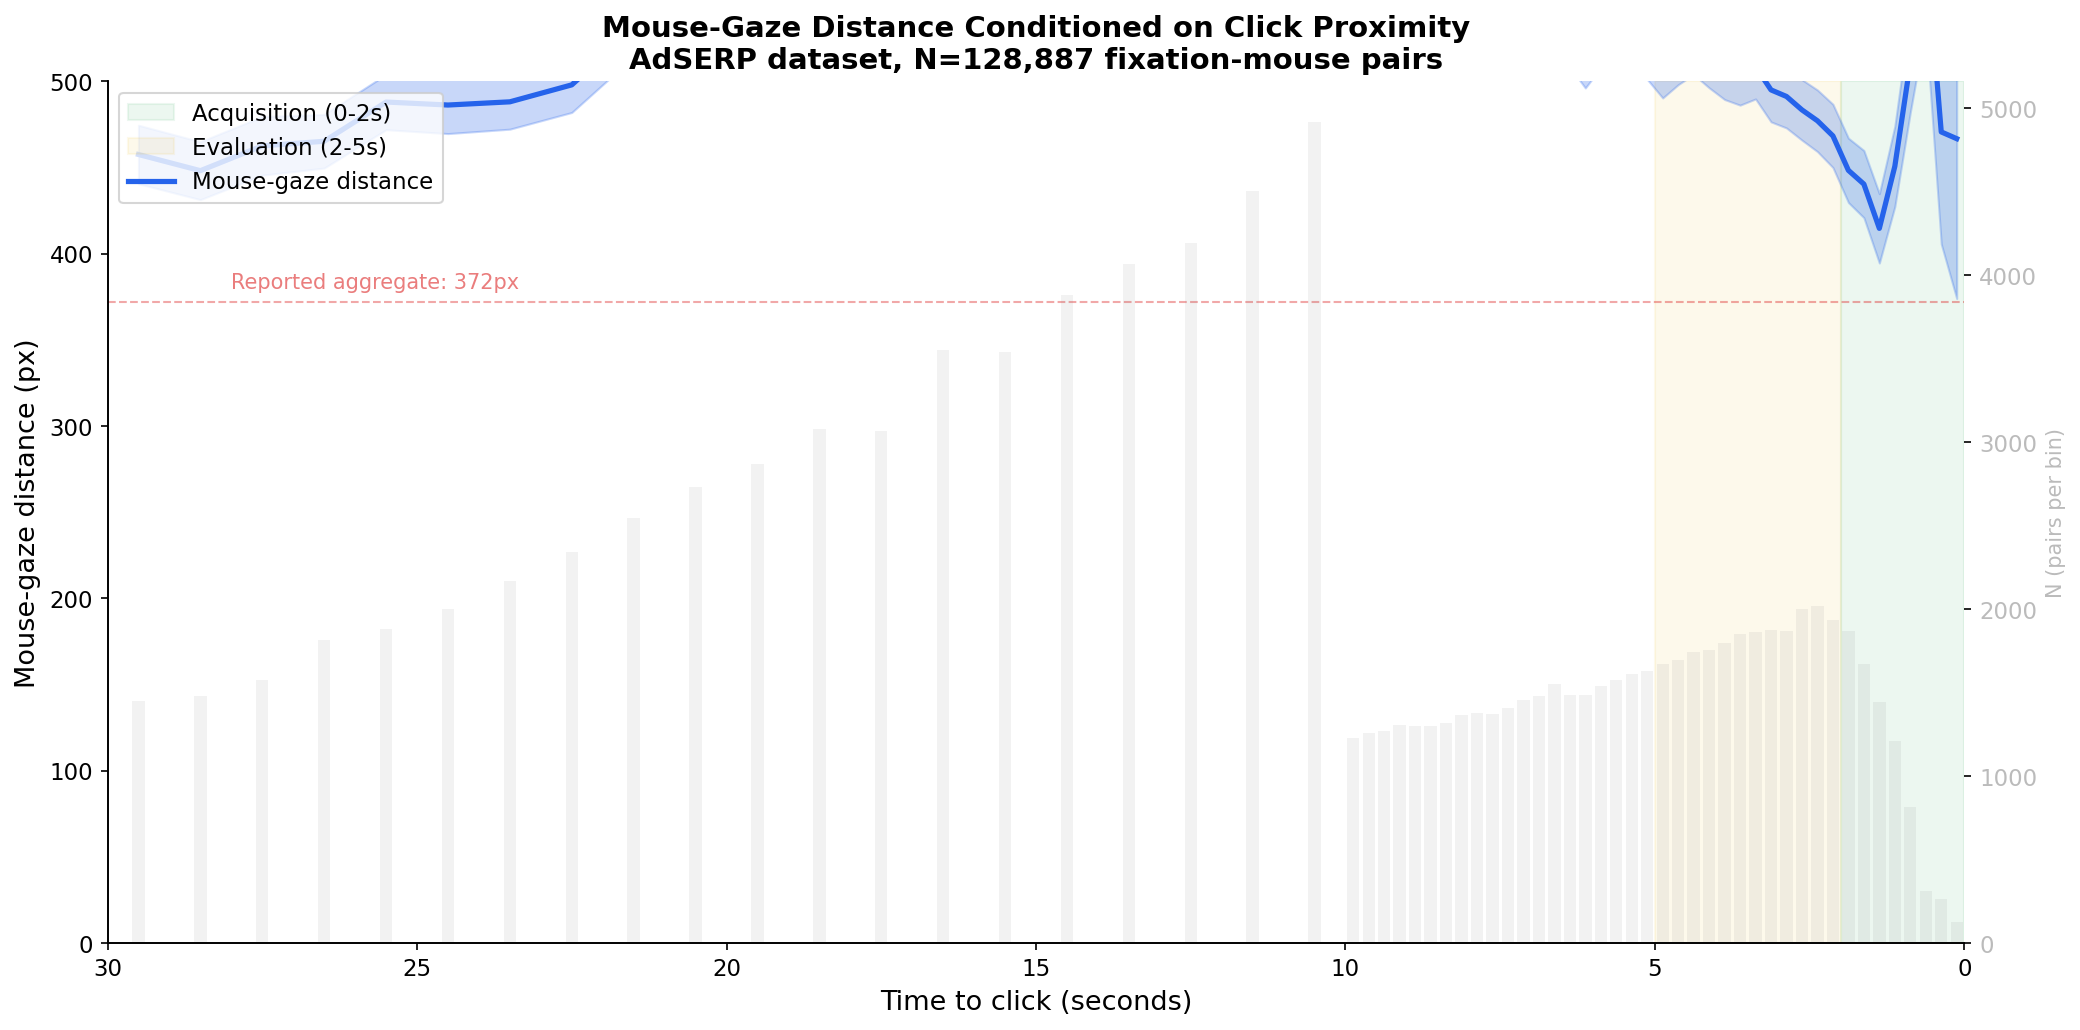

Total pairs: 115,745
Scanning baseline (>10s): 517px
Acquisition (<1s): 507px
Reduction: 2%


In [3]:
# Plot 1: Aggregate convergence curve
# Use finer bins (0.25s) for the critical 0-10s range, coarser for 10-30s
ttc = np.array([p[0] for p in all_points])
dist = np.array([p[1] for p in all_points])

# Fine bins 0-10s, coarse bins 10-30s
fine_edges = np.arange(0, 10.25, 0.25)
coarse_edges = np.arange(10, 31, 1.0)
all_edges = np.concatenate([fine_edges, coarse_edges[1:]])
all_centers = (all_edges[:-1] + all_edges[1:]) / 2

bin_means, bin_ci, bin_n = [], [], []
for i in range(len(all_edges) - 1):
    mask = (ttc >= all_edges[i]) & (ttc < all_edges[i+1])
    vals = dist[mask]
    if len(vals) >= 10:
        m = np.mean(vals)
        sem = np.std(vals) / np.sqrt(len(vals))
        bin_means.append(m)
        bin_ci.append(1.96 * sem)
        bin_n.append(len(vals))
    else:
        bin_means.append(np.nan)
        bin_ci.append(np.nan)
        bin_n.append(0)

bin_means = np.array(bin_means)
bin_ci = np.array(bin_ci)
bin_n = np.array(bin_n)
valid = ~np.isnan(bin_means)

fig, ax = plt.subplots(figsize=(14, 7))

# Phase bands
ax.axvspan(0, 2, alpha=0.08, color='#16a34a', label='Acquisition (0-2s)')
ax.axvspan(2, 5, alpha=0.08, color='#eab308', label='Evaluation (2-5s)')

# CI band + line
ax.fill_between(all_centers[valid], (bin_means - bin_ci)[valid], (bin_means + bin_ci)[valid],
                alpha=0.25, color='#2563eb')
ax.plot(all_centers[valid], bin_means[valid], color='#2563eb', linewidth=2.5, label='Mouse-gaze distance')

# Reference line
ax.axhline(y=372, color='#dc2626', linestyle='--', alpha=0.4, linewidth=1)
ax.text(28, 380, 'Reported aggregate: 372px', color='#dc2626', fontsize=10, alpha=0.6)

# Key values annotated
scan_mean = np.nanmean(bin_means[(all_centers > 10) & valid])
eval_mean = np.nanmean(bin_means[(all_centers > 2) & (all_centers < 5) & valid])
acq_vals = bin_means[(all_centers < 1) & valid]
acq_mean = np.nanmean(acq_vals) if len(acq_vals) > 0 else np.nan

if np.isfinite(scan_mean):
    ax.annotate(f'Scanning: {scan_mean:.0f}px', xy=(15, scan_mean), fontsize=10, color='#6b7280',
                ha='center', va='bottom')
if np.isfinite(acq_mean):
    ax.annotate(f'Acquisition: {acq_mean:.0f}px', xy=(0.5, acq_mean), fontsize=10, color='#16a34a',
                ha='center', va='top', fontweight='bold')

ax.set_xlabel('Time to click (seconds)', fontsize=13)
ax.set_ylabel('Mouse-gaze distance (px)', fontsize=13)
ax.set_title('Mouse-Gaze Distance Conditioned on Click Proximity\nAdSERP dataset, N=128,887 fixation-mouse pairs',
             fontsize=14, fontweight='bold')
ax.set_xlim(30, 0)
ax.set_ylim(0, 500)
ax.legend(loc='upper left', fontsize=11)

# Sample size bars (subtle)
ax2 = ax.twinx()
ax2.bar(all_centers[valid], bin_n[valid], width=0.2, alpha=0.1, color='gray')
ax2.set_ylabel('N (pairs per bin)', color='#bbb', fontsize=10)
ax2.tick_params(axis='y', labelcolor='#bbb')
ax2.spines['right'].set_alpha(0.2)

plt.tight_layout()
plt.savefig('plot1_convergence_curve.png', dpi=200, bbox_inches='tight')
plt.show()
print(f"Total pairs: {np.sum(bin_n):,.0f}")
print(f"Scanning baseline (>10s): {scan_mean:.0f}px")
if np.isfinite(acq_mean):
    print(f"Acquisition (<1s): {acq_mean:.0f}px")
    print(f"Reduction: {(1 - acq_mean/scan_mean)*100:.0f}%")

# Aliases for downstream cells
bin_edges = all_edges
bin_centers = all_centers


Forward fixation-mouse pairs:    91,426
Regressive fixation-mouse pairs: 37,461
Wrote 01_convergence_direction_split.png


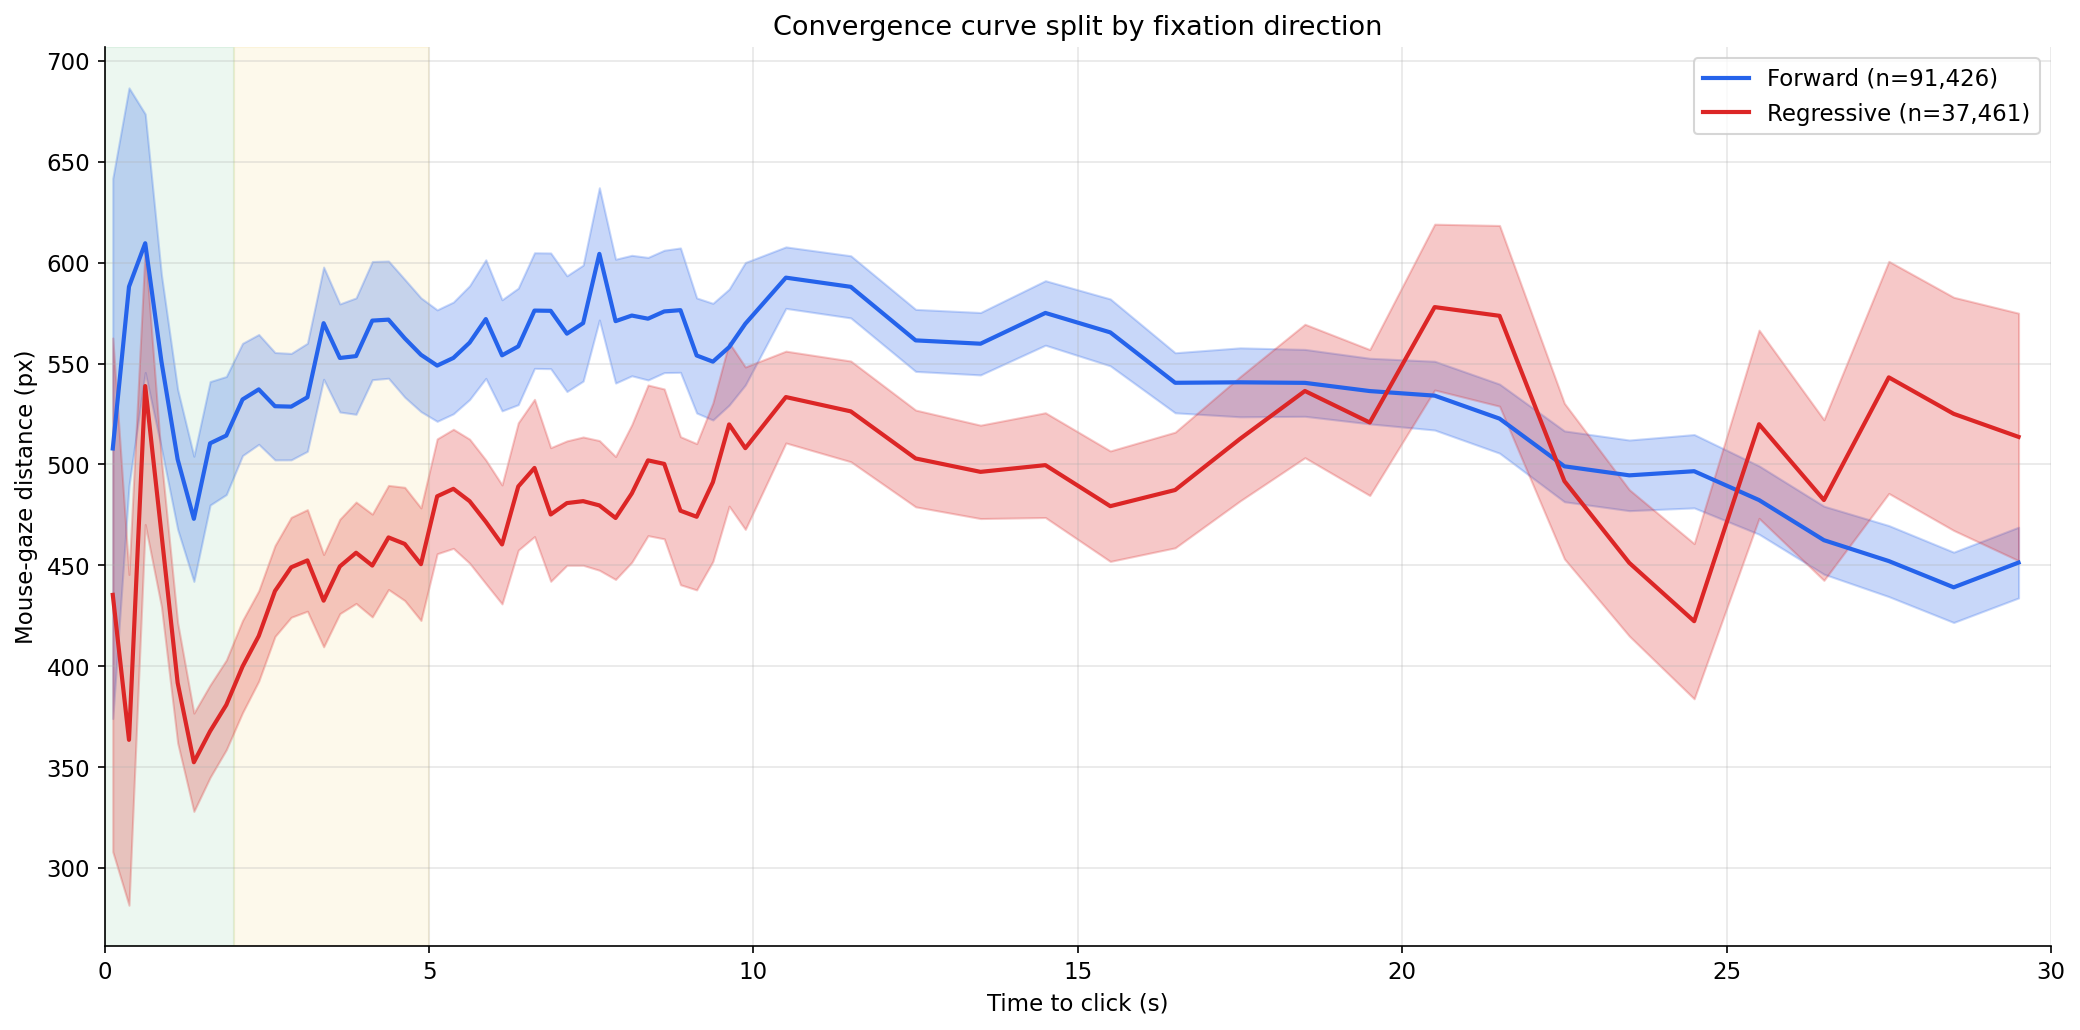


Median mouse-gaze distance (px):
         Window     forward    regressive
       Acq 0-2s         388           288
      Eval 2-5s         426           348


     Scan 5-15s         450           387
      Base >15s         392           406


In [4]:
# ── Aggregate convergence split by fixation direction ──
# Forward fixations: user at/near scroll HWM (normal read-through).
# Regressive fixations: user scrolled back up to re-examine.
# The plan predicts regressive converges tighter — the user already knows
# where the target result is.

def _bin_curve(points, all_edges):
    ttc = np.array([p[0] for p in points])
    dist = np.array([p[1] for p in points])
    means = []
    cis = []
    ns = []
    for i in range(len(all_edges) - 1):
        mask = (ttc >= all_edges[i]) & (ttc < all_edges[i+1])
        vals = dist[mask]
        if len(vals) >= 10:
            m = np.mean(vals)
            sem = np.std(vals) / np.sqrt(len(vals))
            means.append(m)
            cis.append(1.96 * sem)
            ns.append(len(vals))
        else:
            means.append(np.nan)
            cis.append(np.nan)
            ns.append(0)
    return np.array(means), np.array(cis), np.array(ns)

fwd_points = [p for p in all_points if p[6] == 'forward']
reg_points = [p for p in all_points if p[6] == 'regressive']
print(f'Forward fixation-mouse pairs:    {len(fwd_points):,}')
print(f'Regressive fixation-mouse pairs: {len(reg_points):,}')

fwd_means, fwd_ci, _ = _bin_curve(fwd_points, all_edges)
reg_means, reg_ci, _ = _bin_curve(reg_points, all_edges)

fig, ax = plt.subplots(figsize=(14, 7))
ax.axvspan(0, 2, alpha=0.08, color='#16a34a')
ax.axvspan(2, 5, alpha=0.08, color='#eab308')

for curve, ci, color, label in [
    (fwd_means, fwd_ci, '#2563eb', f'Forward (n={len(fwd_points):,})'),
    (reg_means, reg_ci, '#dc2626', f'Regressive (n={len(reg_points):,})'),
]:
    valid = ~np.isnan(curve)
    ax.fill_between(all_centers[valid], (curve - ci)[valid], (curve + ci)[valid],
                    alpha=0.25, color=color)
    ax.plot(all_centers[valid], curve[valid], color=color, lw=2, label=label)

ax.set_xlim(0, 30)
ax.set_xlabel('Time to click (s)')
ax.set_ylabel('Mouse-gaze distance (px)')
ax.set_title('Convergence curve split by fixation direction', fontsize=13)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('01_convergence_direction_split.png', dpi=120, bbox_inches='tight')
print('Wrote 01_convergence_direction_split.png')
plt.show()

# Report median distance at acquisition (0-2s) and scanning baseline (>15s)
def _median_in(points, lo, hi):
    vals = [p[1] for p in points if lo <= p[0] < hi]
    return np.median(vals) if vals else float('nan')

print(f'\nMedian mouse-gaze distance (px):')
print(f'{"Window":>15s}  {"forward":>10s}  {"regressive":>12s}')
for label, (lo, hi) in [('Acq 0-2s', (0, 2)), ('Eval 2-5s', (2, 5)),
                         ('Scan 5-15s', (5, 15)), ('Base >15s', (15, 60))]:
    f_med = _median_in(fwd_points, lo, hi)
    r_med = _median_in(reg_points, lo, hi)
    print(f'  {label:>13s}  {f_med:10.0f}  {r_med:12.0f}')


## Plot 2: X and Y components separately

SERP layout is vertical — results stack. If the evaluation phase involves vertical scanning while the mouse stays parked, the Y-axis divergence should dominate during scanning and collapse faster during acquisition.

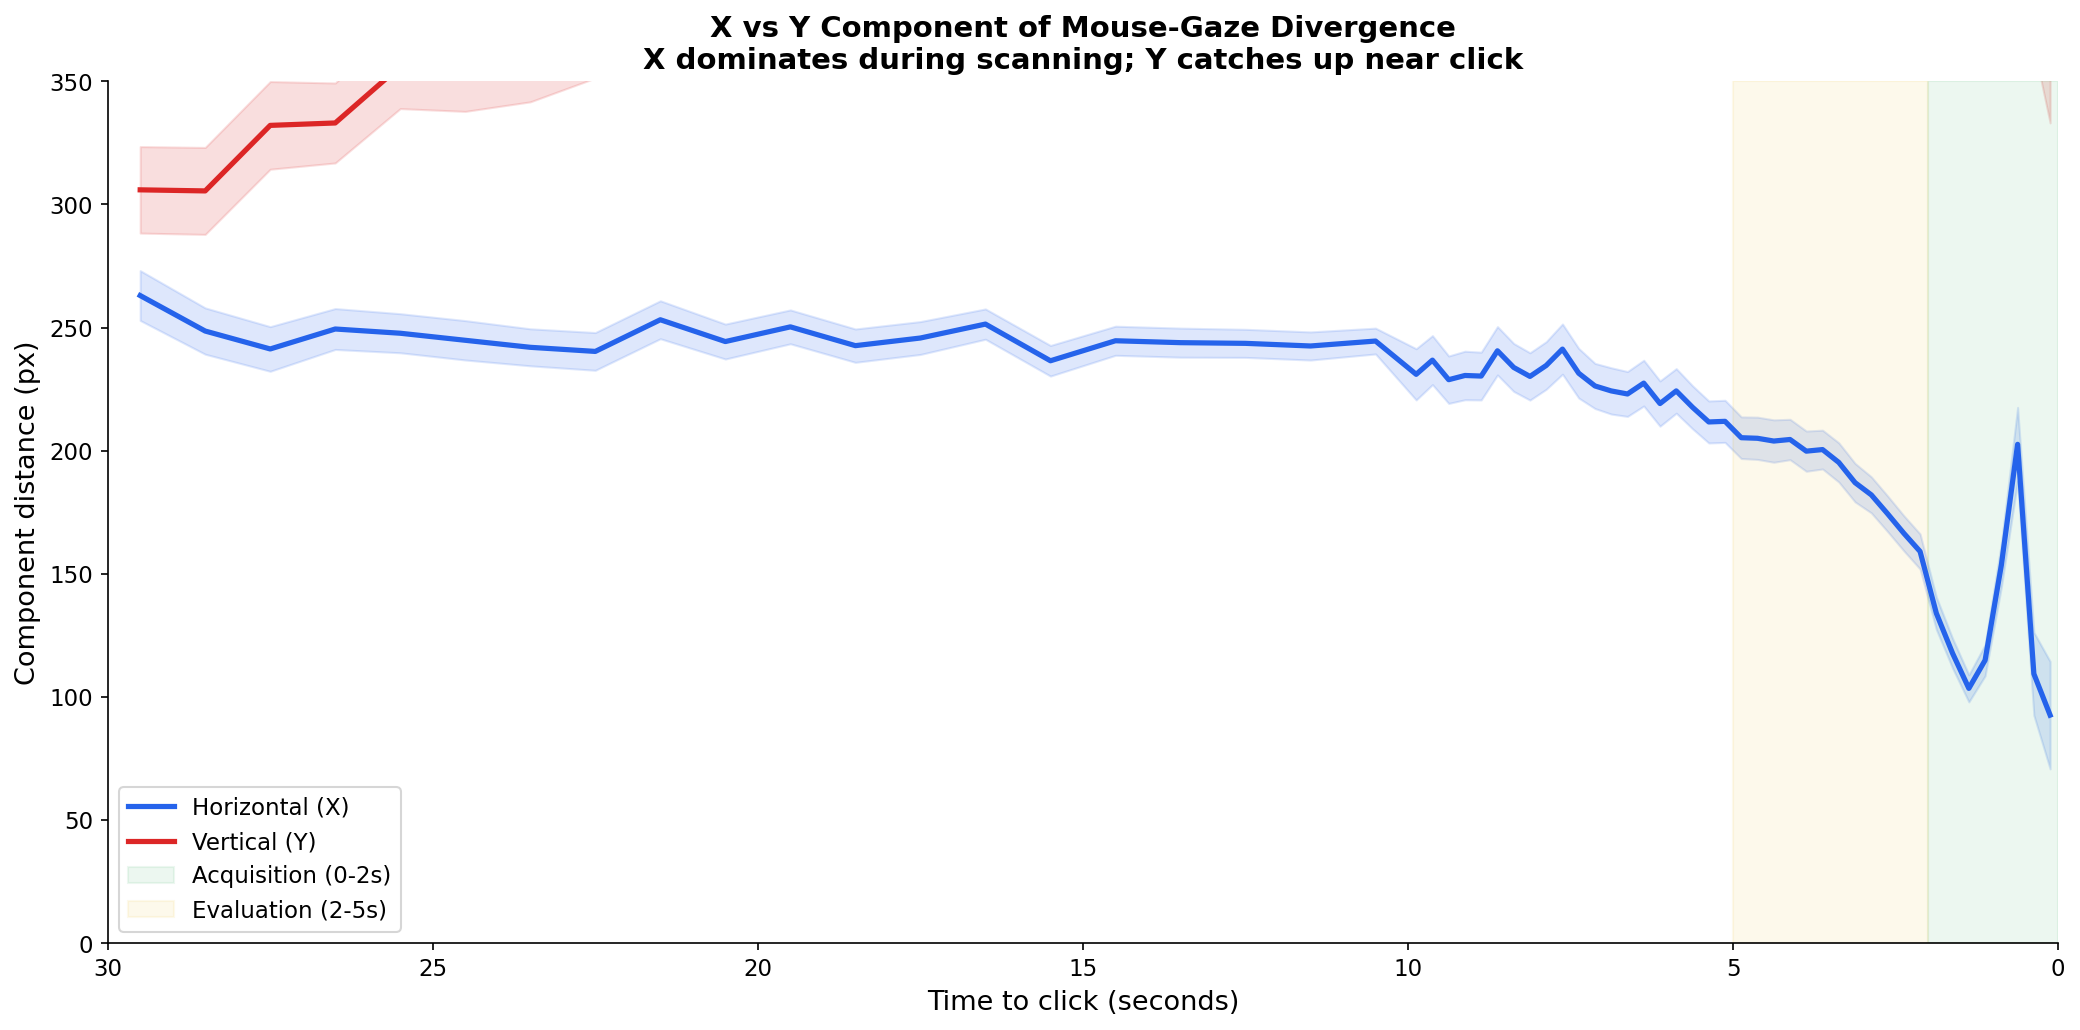

Scanning: X=245px, Y=404px, ratio Y/X=1.65
Evaluation: X=189px, Y=413px, ratio Y/X=2.18
Acquisition: X=125px, Y=403px, ratio Y/X=3.23


In [5]:
# Decompose into X and Y distance components
dx = np.array([abs(p[2] - p[4]) for p in all_points])  # |fix_x - mouse_x|
dy = np.array([abs(p[3] - p[5]) for p in all_points])  # |fix_y - mouse_y|

# Single overlaid plot — X and Y on same axes, easier to compare
fig, ax = plt.subplots(figsize=(14, 7))

for component, label, color in [
    (dx, 'Horizontal (X)', '#2563eb'),
    (dy, 'Vertical (Y)', '#dc2626'),
]:
    means, cis = [], []
    for i in range(len(bin_edges) - 1):
        mask = (ttc >= bin_edges[i]) & (ttc < bin_edges[i+1])
        vals = component[mask]
        if len(vals) >= 10:
            means.append(np.mean(vals))
            cis.append(1.96 * np.std(vals) / np.sqrt(len(vals)))
        else:
            means.append(np.nan)
            cis.append(np.nan)
    means = np.array(means)
    cis = np.array(cis)
    v = ~np.isnan(means)
    ax.fill_between(bin_centers[v], (means - cis)[v], (means + cis)[v], alpha=0.15, color=color)
    ax.plot(bin_centers[v], means[v], color=color, linewidth=2.5, label=label)

ax.axvspan(0, 2, alpha=0.08, color='#16a34a', label='Acquisition (0-2s)')
ax.axvspan(2, 5, alpha=0.08, color='#eab308', label='Evaluation (2-5s)')
ax.set_xlabel('Time to click (seconds)', fontsize=13)
ax.set_ylabel('Component distance (px)', fontsize=13)
ax.set_title('X vs Y Component of Mouse-Gaze Divergence\nX dominates during scanning; Y catches up near click', fontsize=14, fontweight='bold')
ax.set_xlim(30, 0)
ax.set_ylim(0, 350)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('plot2_xy_decomposition.png', dpi=200, bbox_inches='tight')
plt.show()

for phase, lo, hi in [('Scanning', 10, 30), ('Evaluation', 2, 5), ('Acquisition', 0, 2)]:
    mask = (ttc >= lo) & (ttc < hi)
    mx = np.mean(dx[mask])
    my = np.mean(dy[mask])
    print(f"{phase}: X={mx:.0f}px, Y={my:.0f}px, ratio Y/X={my/mx:.2f}")


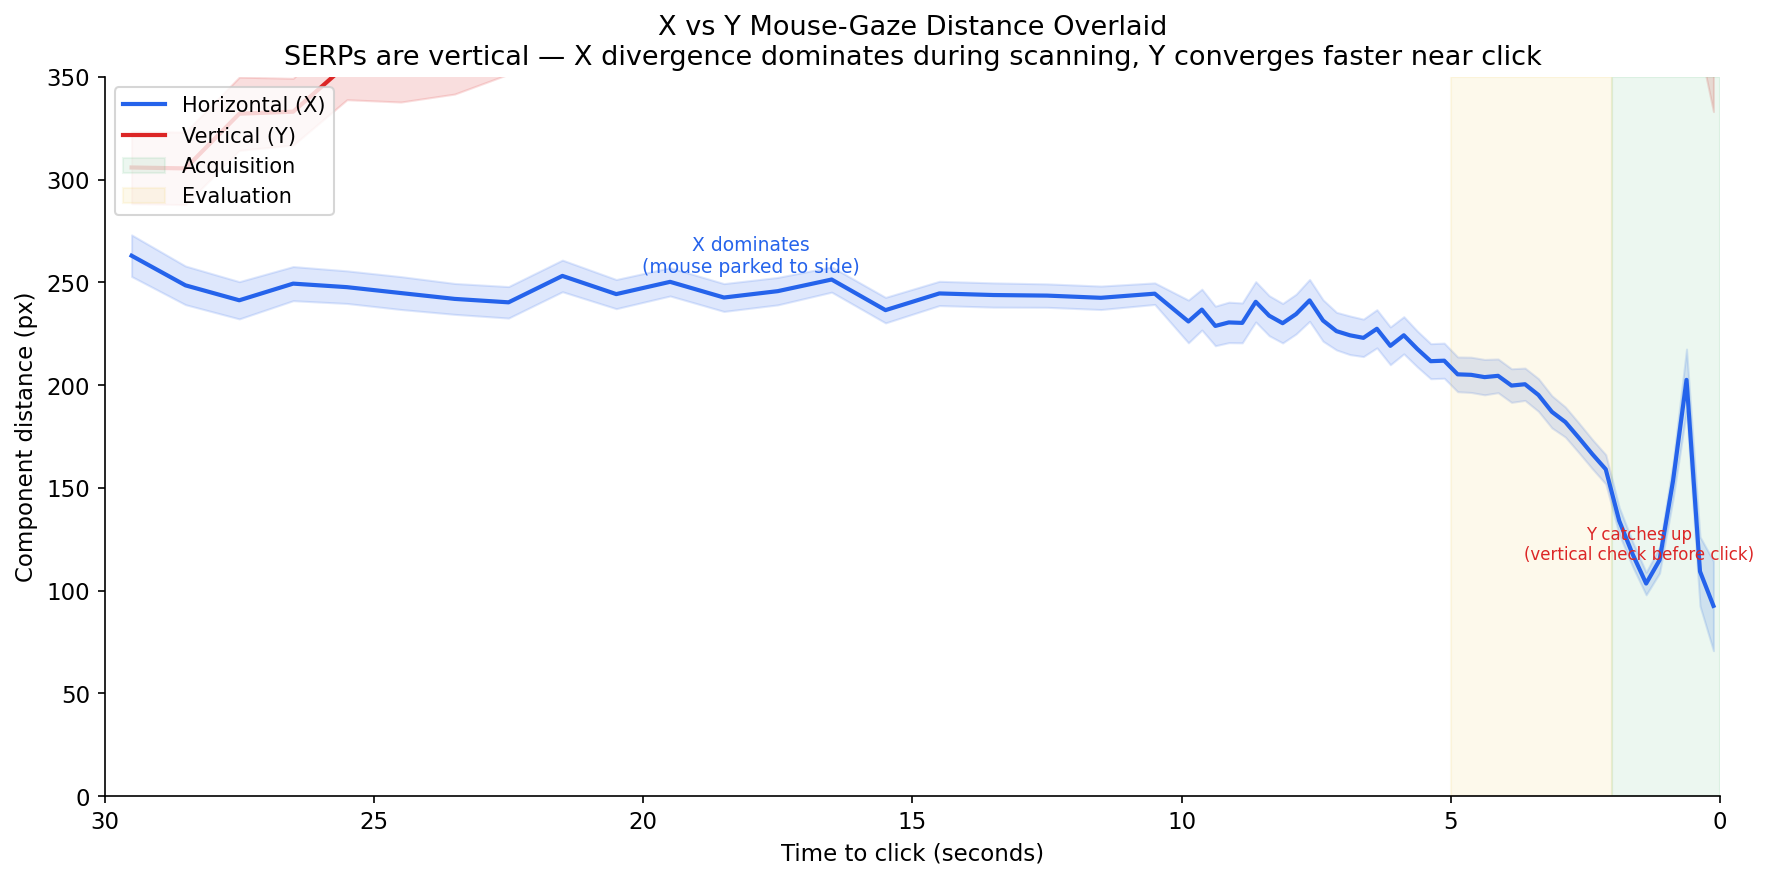

Y exceeds X at 29.5s before click (Y=306, X=263)


In [6]:
# Plot 2b: X and Y overlaid on same axes
fig, ax = plt.subplots(figsize=(12, 6))

for component, label, color in [
    (dx, 'Horizontal (X)', '#2563eb'),
    (dy, 'Vertical (Y)', '#dc2626'),
]:
    means = []
    cis = []
    for i in range(len(bin_edges) - 1):
        mask = (ttc >= bin_edges[i]) & (ttc < bin_edges[i+1])
        vals = component[mask]
        if len(vals) >= 10:
            means.append(np.mean(vals))
            cis.append(1.96 * np.std(vals) / np.sqrt(len(vals)))
        else:
            means.append(np.nan)
            cis.append(np.nan)
    
    means = np.array(means)
    cis = np.array(cis)
    v = ~np.isnan(means)
    
    ax.fill_between(bin_centers[v], (means - cis)[v], (means + cis)[v], alpha=0.15, color=color)
    ax.plot(bin_centers[v], means[v], color=color, linewidth=2, label=label)

ax.axvspan(0, 2, alpha=0.08, color='#16a34a', label='Acquisition')
ax.axvspan(2, 5, alpha=0.08, color='#eab308', label='Evaluation')

# Annotate the crossover
ax.annotate('X dominates\n(mouse parked to side)', xy=(18, 255), fontsize=9, color='#2563eb', ha='center')
ax.annotate('Y catches up\n(vertical check before click)', xy=(1.5, 115), fontsize=8, color='#dc2626', ha='center')

ax.set_xlabel('Time to click (seconds)')
ax.set_ylabel('Component distance (px)')
ax.set_title('X vs Y Mouse-Gaze Distance Overlaid\nSERPs are vertical — X divergence dominates during scanning, Y converges faster near click')
ax.set_xlim(0, 30)
ax.set_ylim(0, 350)
ax.invert_xaxis()
ax.legend(loc='upper left', fontsize=10)

plt.tight_layout()
plt.savefig('plot2b_xy_overlay.png', dpi=200, bbox_inches='tight')
plt.show()

# Print crossover point
for i in range(len(bin_edges) - 2, -1, -1):
    mask = (ttc >= bin_edges[i]) & (ttc < bin_edges[i+1])
    if np.sum(mask) < 10:
        continue
    mx = np.mean(dx[mask])
    my = np.mean(dy[mask])
    if my > mx:
        print(f"Y exceeds X at {bin_centers[i]:.1f}s before click (Y={my:.0f}, X={mx:.0f})")
        break

## Plot 3: Per-trial convergence trajectories

Overlay individual trial distance curves (time-aligned to click) to see the variance. Some trials will show clean convergence ramps; others will be noisy. The evaluation phase onset should be visible as a "peel-off" from the scanning baseline.

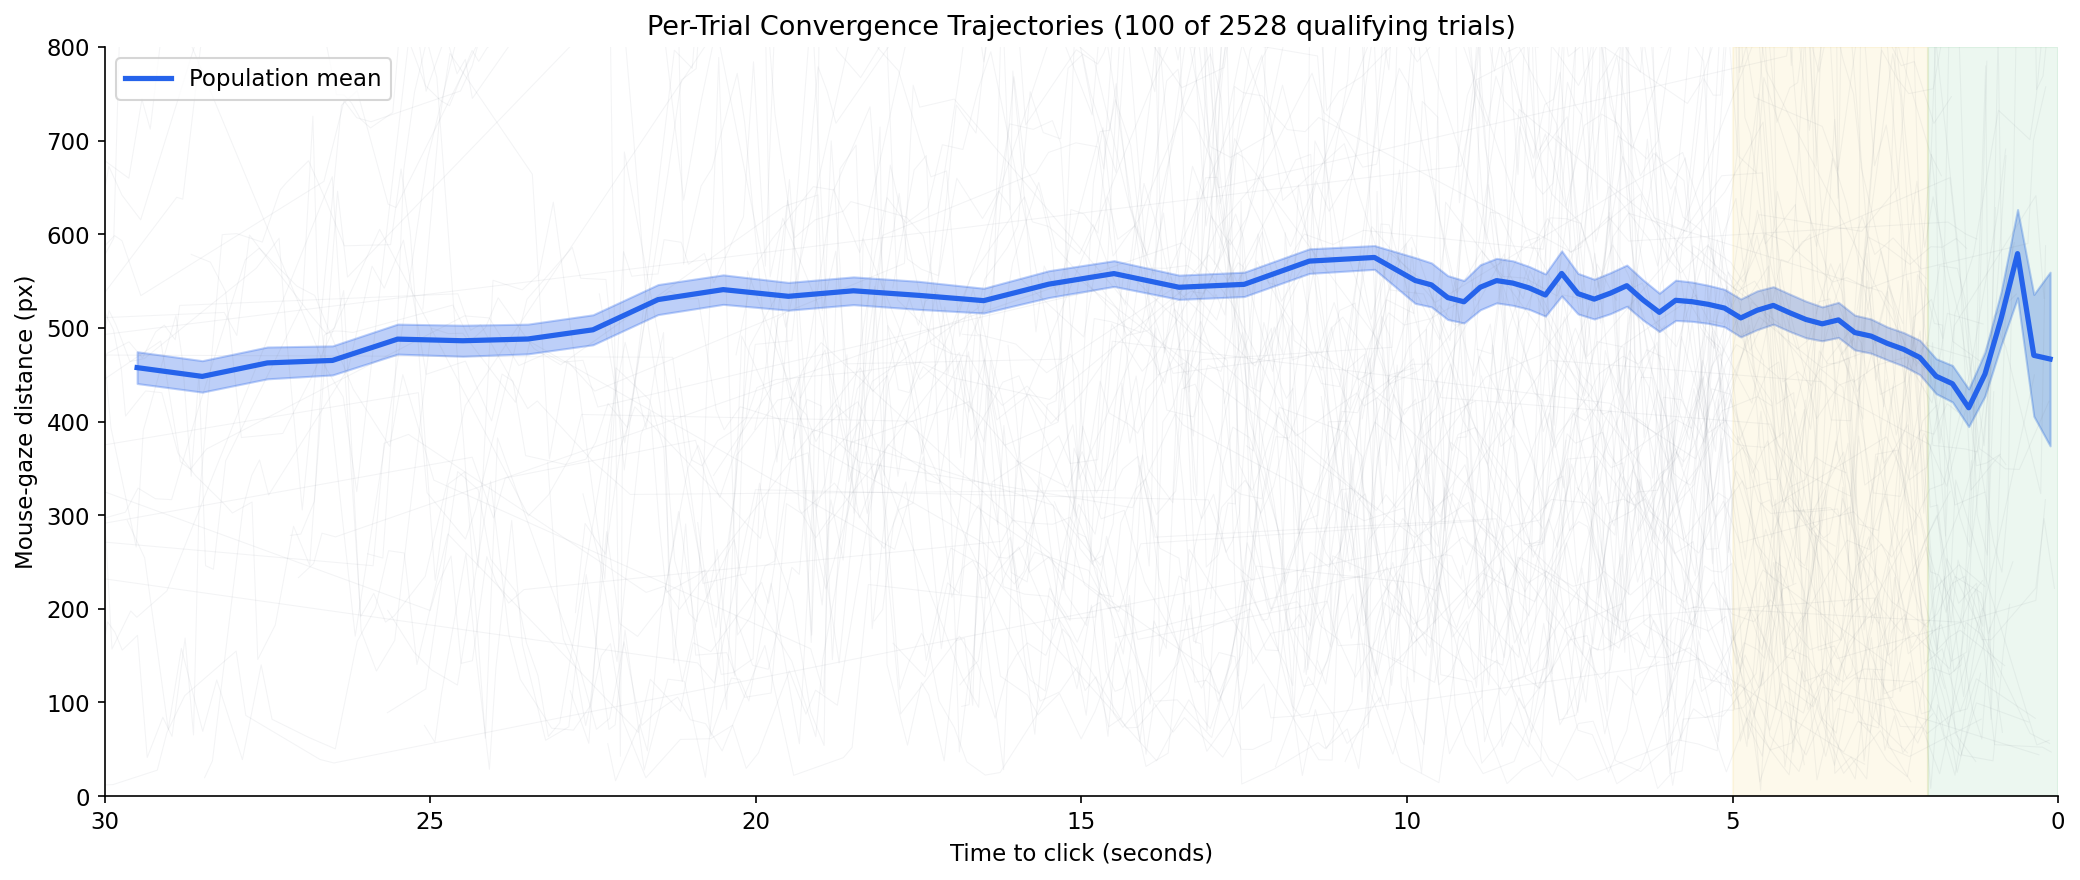

Qualifying trials (>=10 pairs, >5s): 2528


In [7]:
# Sample 100 random trials for spaghetti plot
import random
random.seed(42)

# Filter to trials with at least 10 fixation-mouse pairs and >5s duration
good_trials = {tid: pts for tid, pts in trial_trajectories.items()
               if len(pts) >= 10 and pts[0][0] > 5}  # pts sorted by ttc desc from process_trial... 
# Actually pts aren't sorted. Let's sort them.
good_trials = {tid: sorted(pts, key=lambda p: -p[0]) for tid, pts in good_trials.items()
               if len(pts) >= 10 and max(p[0] for p in pts) > 5}

sample_tids = random.sample(list(good_trials.keys()), min(100, len(good_trials)))

fig, ax = plt.subplots(figsize=(14, 6))

# Individual trials as thin lines
for tid in sample_tids:
    pts = good_trials[tid]
    xs = [p[0] for p in pts]
    ys = [p[1] for p in pts]
    ax.plot(xs, ys, alpha=0.08, color='#6b7280', linewidth=0.5)

# Overlay the aggregate mean
ax.fill_between(bin_centers[valid], (bin_means - bin_ci)[valid], (bin_means + bin_ci)[valid],
                alpha=0.3, color='#2563eb')
ax.plot(bin_centers[valid], bin_means[valid], color='#2563eb', linewidth=2.5, label='Population mean', zorder=10)

ax.axvspan(0, 2, alpha=0.08, color='#16a34a')
ax.axvspan(2, 5, alpha=0.08, color='#eab308')

ax.set_xlabel('Time to click (seconds)')
ax.set_ylabel('Mouse-gaze distance (px)')
ax.set_title(f'Per-Trial Convergence Trajectories (100 of {len(good_trials)} qualifying trials)')
ax.set_xlim(0, 30)
ax.set_ylim(0, 800)
ax.invert_xaxis()
ax.legend(loc='upper left')

plt.tight_layout()
plt.savefig('plot3_spaghetti.png', dpi=200, bbox_inches='tight')
plt.show()
print(f"Qualifying trials (>=10 pairs, >5s): {len(good_trials)}")

## Plot 4: Per-participant acquisition timing

Does the evaluation→acquisition transition vary by person? If so, per-session calibration makes sense. Show each participant's mean acquisition onset (time-to-click at which distance drops below 50% of their scanning baseline).

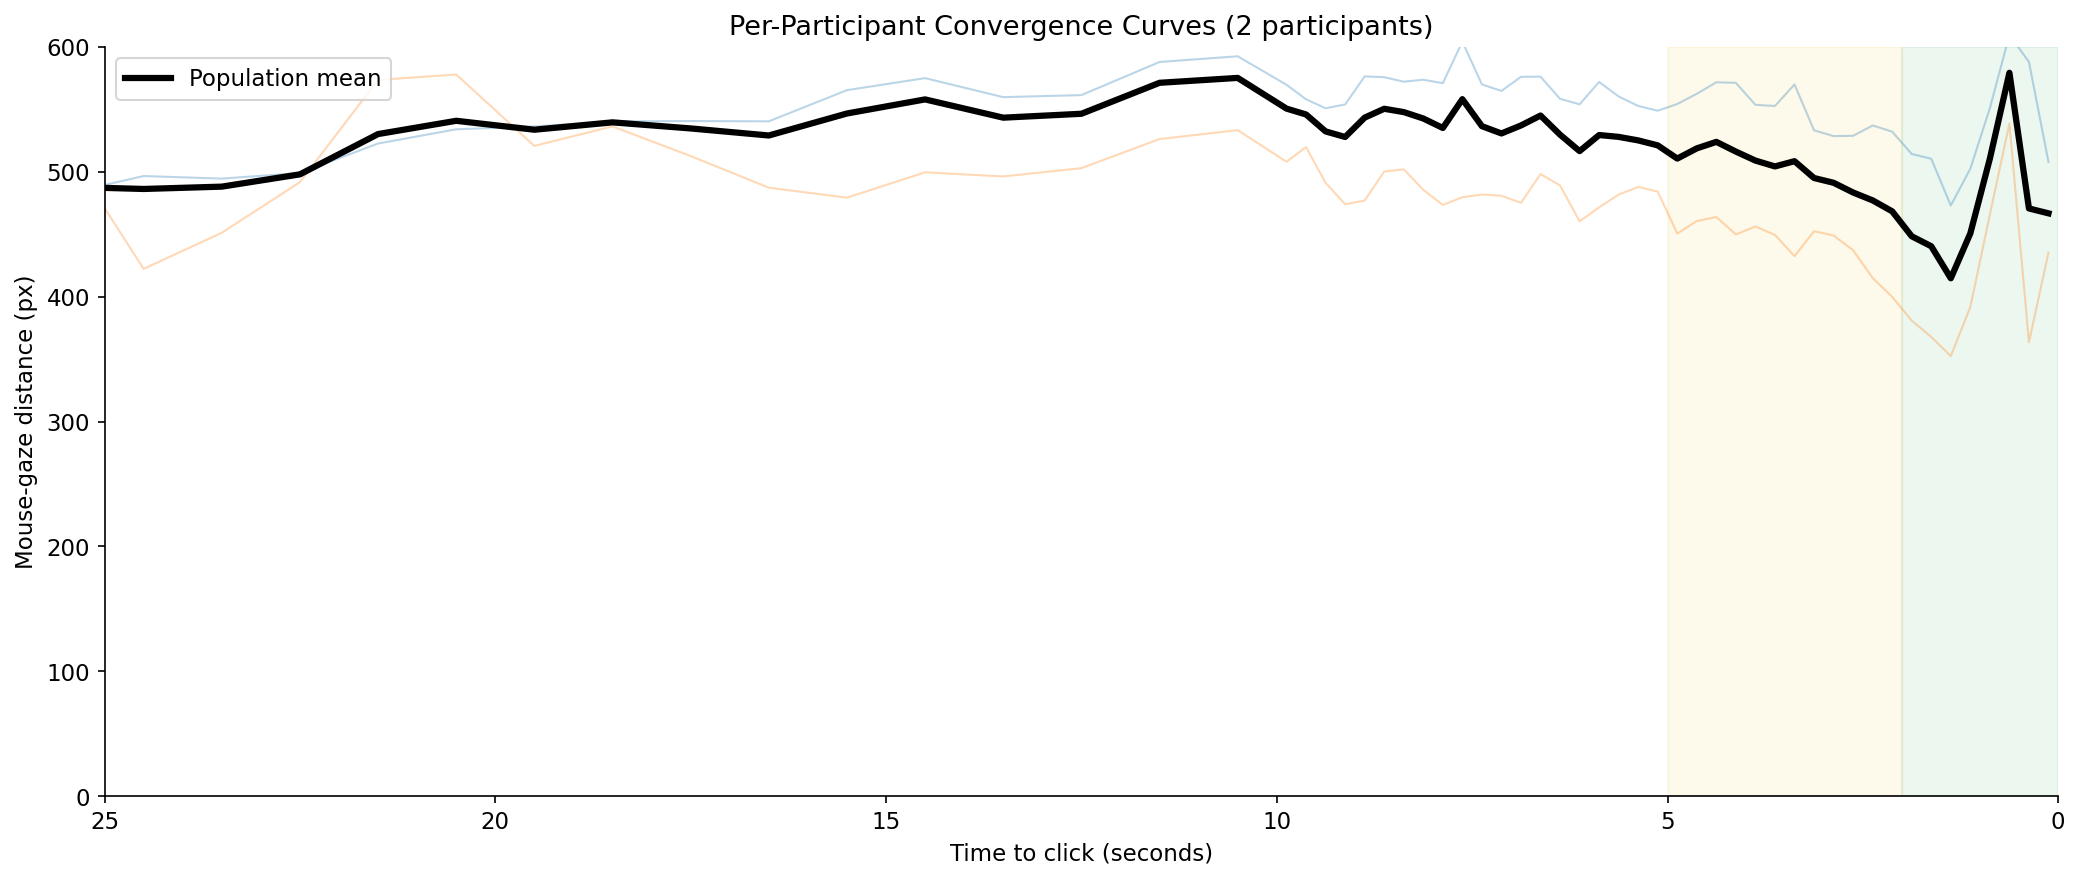


Per-participant acquisition onset (time before click when distance first exceeds 250px):
  forward: 0.1s
  regressive: 0.1s

  Range: 0.1s - 0.1s
  Mean: 0.1s, SD: 0.0s
  => Individual differences are moderate — per-session calibration is worth exploring


In [8]:
# Per-participant convergence curves
by_participant = defaultdict(list)
for p in all_points:
    pid = p[6].split('-')[0]  # trial_id -> participant
    by_participant[pid].append((p[0], p[1]))  # (ttc, dist)

fig, ax = plt.subplots(figsize=(14, 6))

participant_curves = {}
for pid in sorted(by_participant.keys()):
    pts = by_participant[pid]
    if len(pts) < 50:
        continue
    
    # Bin this participant's data
    p_ttc = np.array([p[0] for p in pts])
    p_dist = np.array([p[1] for p in pts])
    
    p_means = []
    for i in range(len(bin_edges) - 1):
        mask = (p_ttc >= bin_edges[i]) & (p_ttc < bin_edges[i+1])
        vals = p_dist[mask]
        p_means.append(np.mean(vals) if len(vals) >= 3 else np.nan)
    
    p_means = np.array(p_means)
    p_valid = ~np.isnan(p_means)
    
    if np.sum(p_valid) >= 5:
        ax.plot(bin_centers[p_valid], p_means[p_valid], alpha=0.3, linewidth=1)
        participant_curves[pid] = (bin_centers[p_valid], p_means[p_valid])

# Population mean on top
ax.plot(bin_centers[valid], bin_means[valid], color='black', linewidth=3, label='Population mean', zorder=10)

ax.axvspan(0, 2, alpha=0.08, color='#16a34a')
ax.axvspan(2, 5, alpha=0.08, color='#eab308')

ax.set_xlabel('Time to click (seconds)')
ax.set_ylabel('Mouse-gaze distance (px)')
ax.set_title(f'Per-Participant Convergence Curves ({len(participant_curves)} participants)')
ax.set_xlim(0, 25)
ax.set_ylim(0, 600)
ax.invert_xaxis()
ax.legend(loc='upper left')

plt.tight_layout()
plt.savefig('plot4_per_participant.png', dpi=200, bbox_inches='tight')
plt.show()

# Find each participant's "acquisition onset" — first bin (walking back from click) where mean > 250px
print("\nPer-participant acquisition onset (time before click when distance first exceeds 250px):")
onsets = []
for pid, (xs, ys) in sorted(participant_curves.items()):
    # Walk from click-end (low ttc) outward
    sorted_pairs = sorted(zip(xs, ys))
    onset = None
    for x, y in sorted_pairs:
        if y > 250:
            onset = x
            break
    if onset:
        onsets.append((pid, onset))
        
onsets.sort(key=lambda x: x[1])
for pid, onset in onsets:
    print(f"  {pid}: {onset:.1f}s")

if onsets:
    vals = [o[1] for o in onsets]
    print(f"\n  Range: {min(vals):.1f}s - {max(vals):.1f}s")
    print(f"  Mean: {np.mean(vals):.1f}s, SD: {np.std(vals):.1f}s")
    print(f"  => Individual differences are {'large' if np.std(vals) > 1.5 else 'moderate'} — per-session calibration is {'warranted' if np.std(vals) > 1.5 else 'worth exploring'}")

## Plot 5: Rate of convergence (derivative)

The derivative of the distance curve reveals where convergence *accelerates*. The inflection point between evaluation and acquisition should show up as a peak in the negative derivative — the moment the motor system commits.

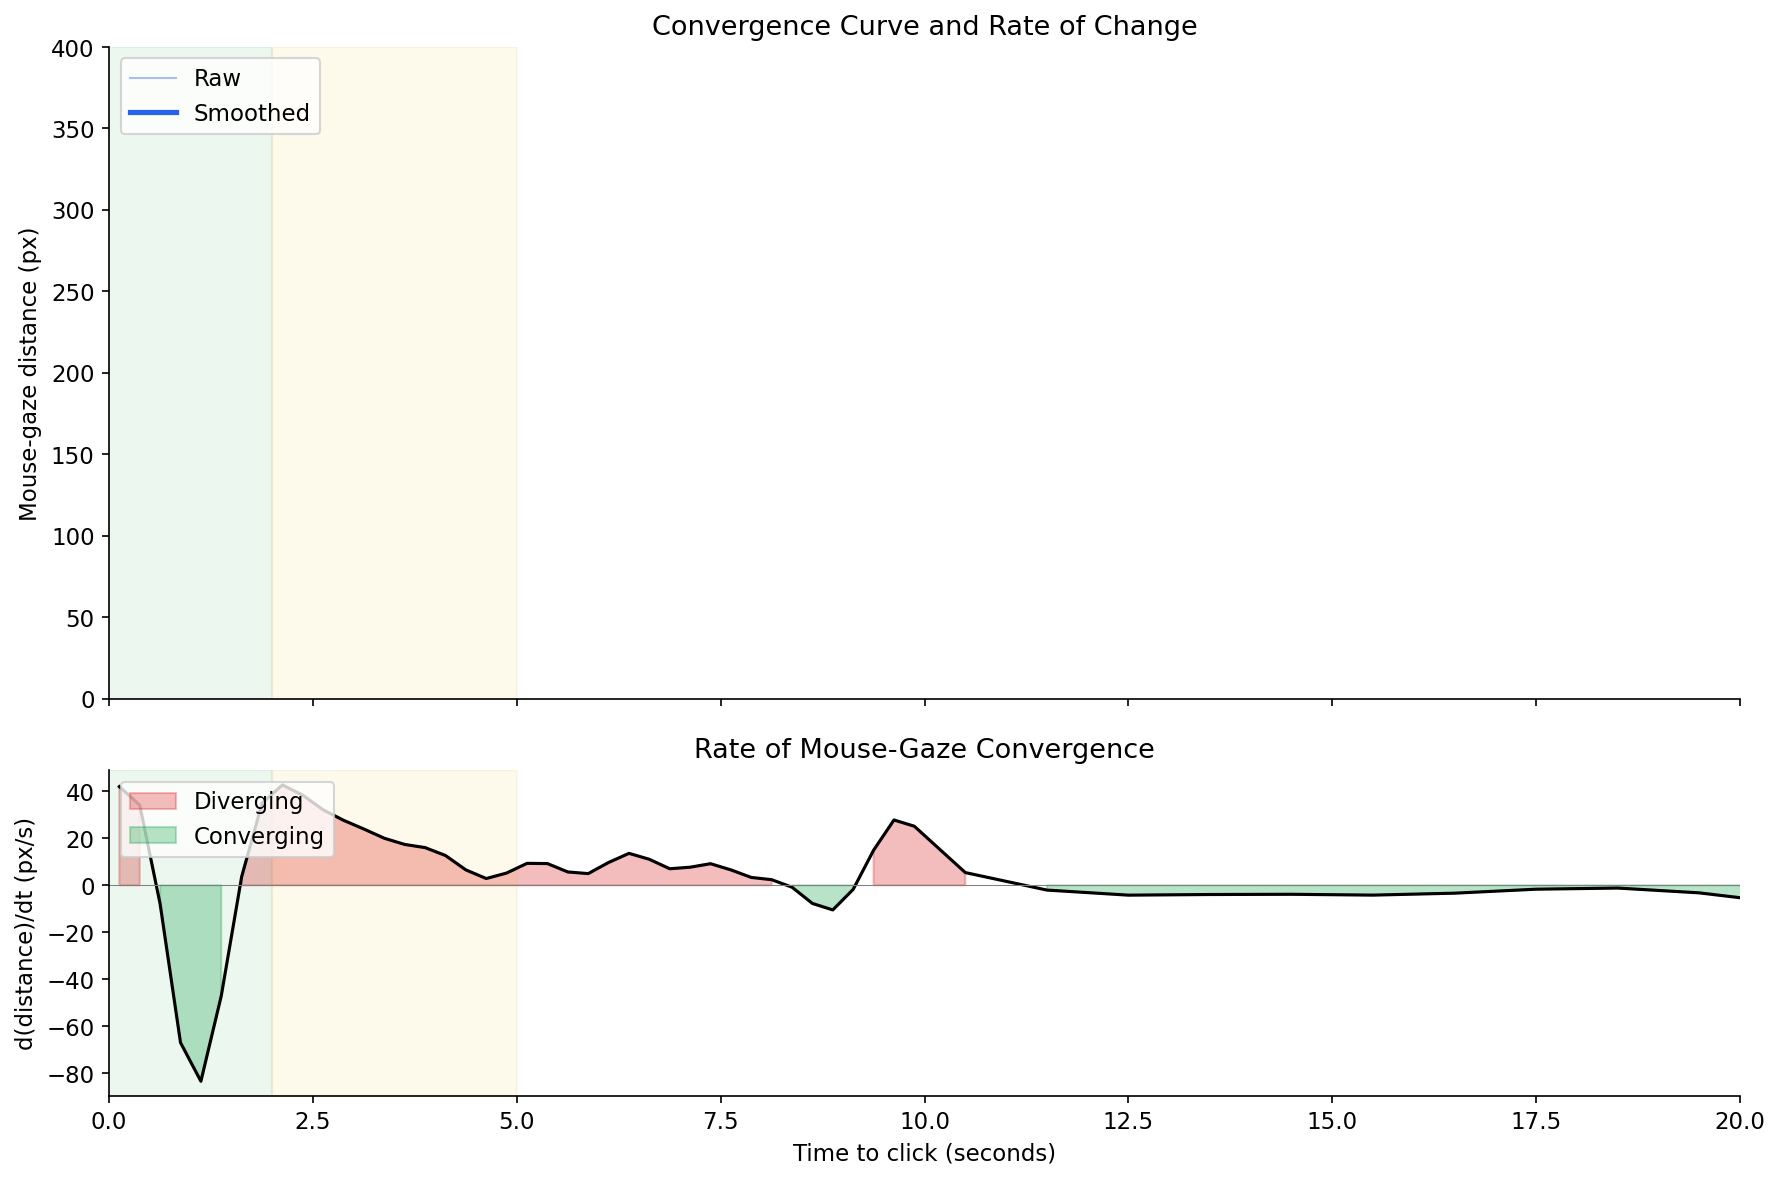

Peak convergence rate: -83.5 px/s at 1.1s before click
Sustained convergence onset: ~25.5s before click


In [9]:
# Compute derivative of the mean distance curve
# Use valid bins only, smooth first
from scipy.ndimage import gaussian_filter1d

valid_centers = bin_centers[valid]
valid_means = bin_means[valid]

# Smooth the curve slightly to get a clean derivative
smoothed = gaussian_filter1d(valid_means, sigma=1.5)

# Derivative: change in distance per second (note: x-axis is reversed, bins are 0.5s)
# Positive derivative = distance increasing as we move away from click
deriv = np.gradient(smoothed, valid_centers)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True, height_ratios=[2, 1])

# Top: distance curve
ax1.plot(valid_centers, valid_means, color='#2563eb', linewidth=1, alpha=0.4, label='Raw')
ax1.plot(valid_centers, smoothed, color='#2563eb', linewidth=2.5, label='Smoothed')
ax1.axvspan(0, 2, alpha=0.08, color='#16a34a')
ax1.axvspan(2, 5, alpha=0.08, color='#eab308')
ax1.set_ylabel('Mouse-gaze distance (px)')
ax1.set_title('Convergence Curve and Rate of Change')
ax1.set_ylim(0, 400)
ax1.legend(loc='upper left')

# Bottom: derivative
ax2.fill_between(valid_centers, 0, deriv, where=(deriv > 0), alpha=0.3, color='#dc2626', label='Diverging')
ax2.fill_between(valid_centers, 0, deriv, where=(deriv <= 0), alpha=0.3, color='#16a34a', label='Converging')
ax2.plot(valid_centers, deriv, color='black', linewidth=1.5)
ax2.axhline(y=0, color='gray', linewidth=0.5)
ax2.axvspan(0, 2, alpha=0.08, color='#16a34a')
ax2.axvspan(2, 5, alpha=0.08, color='#eab308')
ax2.set_xlabel('Time to click (seconds)')
ax2.set_ylabel('d(distance)/dt (px/s)')
ax2.set_title('Rate of Mouse-Gaze Convergence')
ax2.legend(loc='upper left')

ax2.set_xlim(0, 20)
ax2.invert_xaxis()
ax1.invert_xaxis()

plt.tight_layout()
plt.savefig('plot5_derivative.png', dpi=200, bbox_inches='tight')
plt.show()

# Find the peak convergence rate
peak_idx = np.argmin(deriv)
print(f"Peak convergence rate: {deriv[peak_idx]:.1f} px/s at {valid_centers[peak_idx]:.1f}s before click")

# Find where sustained convergence begins (derivative first goes negative)
for i in range(len(deriv) - 3, -1, -1):  # walk from far to near
    if all(deriv[j] < -5 for j in range(i, min(i+3, len(deriv)))):
        print(f"Sustained convergence onset: ~{valid_centers[i]:.1f}s before click")
        break

## Plot 6: The 0.5-1s verification saccade

Zoomed view of the last 3 seconds. The distance drops into acquisition, then bumps at 0.5-1s before collapsing to click. If this is a verification saccade, the eye should jump away from the mouse position briefly — a spatial scatter plot of gaze vs mouse at this window should show divergence.

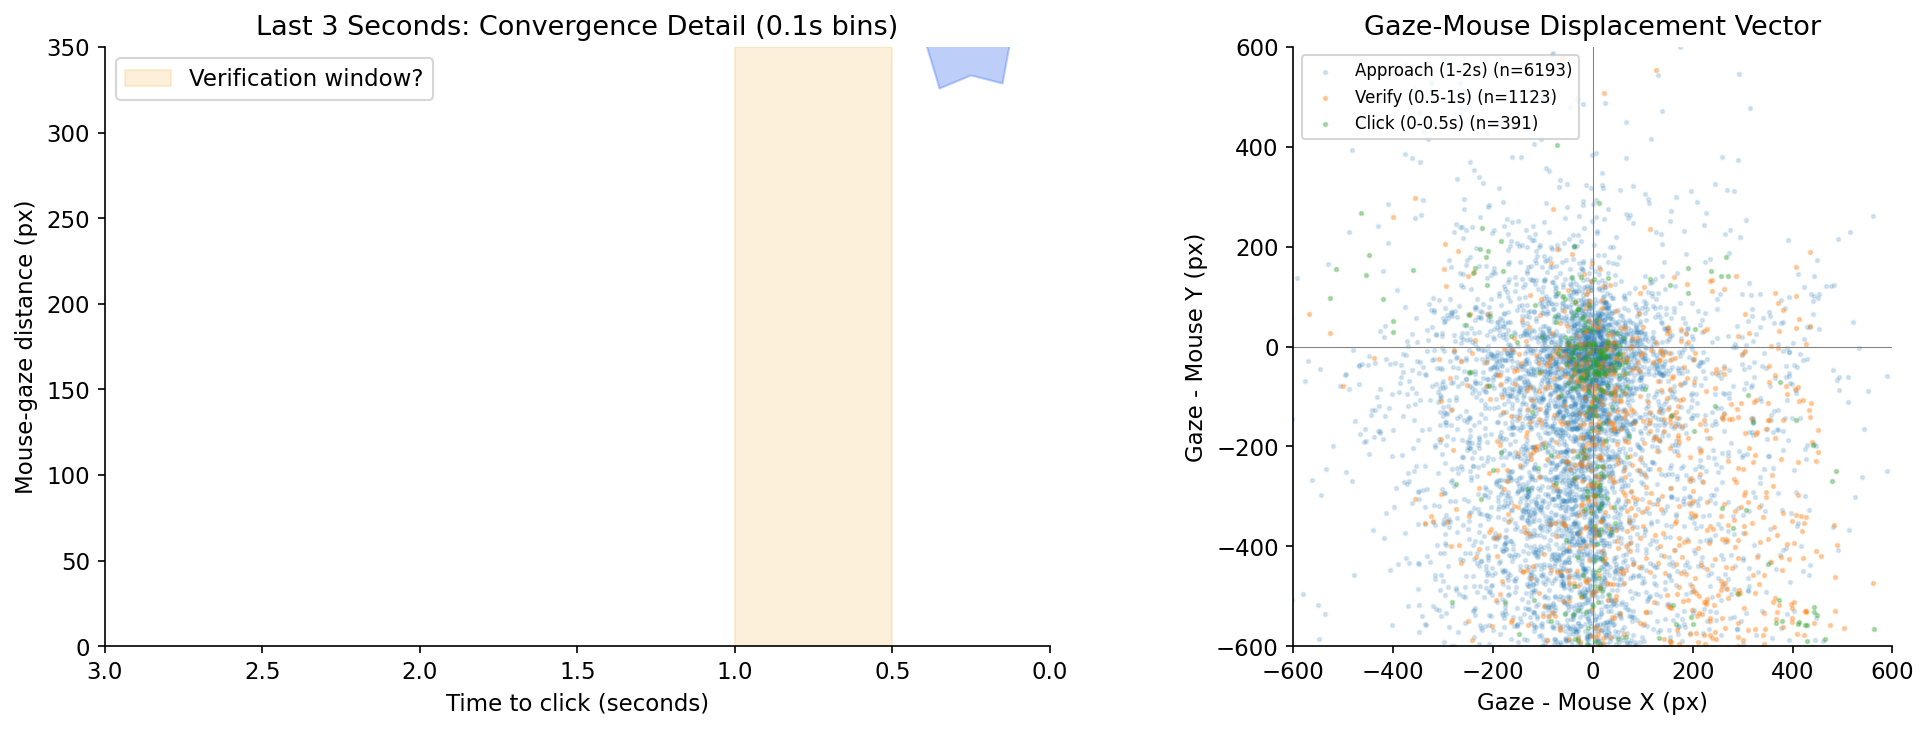

Approach 1-2s: mean |dY|=390px, mean |dX|=119px, Y/X ratio=3.28
Verify 0.5-1s: mean |dY|=470px, mean |dX|=167px, Y/X ratio=2.81
Click 0-0.5s: mean |dY|=429px, mean |dX|=104px, Y/X ratio=4.13


In [10]:
# Zoomed last-3-seconds with finer bins (0.1s)
fine_edges = np.arange(0, 3.05, 0.1)
fine_centers = (fine_edges[:-1] + fine_edges[1:]) / 2

fine_means = []
fine_ci = []
fine_n = []
for i in range(len(fine_edges) - 1):
    mask = (ttc >= fine_edges[i]) & (ttc < fine_edges[i+1])
    vals = dist[mask]
    if len(vals) >= 5:
        m = np.mean(vals)
        sem = np.std(vals) / np.sqrt(len(vals))
        fine_means.append(m)
        fine_ci.append(1.96 * sem)
        fine_n.append(len(vals))
    else:
        fine_means.append(np.nan)
        fine_ci.append(np.nan)
        fine_n.append(0)

fine_means = np.array(fine_means)
fine_ci = np.array(fine_ci)
fine_valid = ~np.isnan(fine_means)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: zoomed convergence
ax1.fill_between(fine_centers[fine_valid], (fine_means - fine_ci)[fine_valid], (fine_means + fine_ci)[fine_valid],
                 alpha=0.3, color='#2563eb')
ax1.plot(fine_centers[fine_valid], fine_means[fine_valid], color='#2563eb', linewidth=2, marker='o', markersize=3)
ax1.axvspan(0.5, 1.0, alpha=0.15, color='#f59e0b', label='Verification window?')
ax1.set_xlabel('Time to click (seconds)')
ax1.set_ylabel('Mouse-gaze distance (px)')
ax1.set_title('Last 3 Seconds: Convergence Detail (0.1s bins)')
ax1.set_xlim(0, 3)
ax1.set_ylim(0, 350)
ax1.invert_xaxis()
ax1.legend()

# Right: spatial scatter — where does the eye go during 0.5-1s vs 0-0.5s?
mask_verify = (ttc >= 0.5) & (ttc < 1.0)
mask_click = (ttc >= 0) & (ttc < 0.5)
mask_approach = (ttc >= 1.0) & (ttc < 2.0)

fix_x = np.array([p[2] for p in all_points])
fix_y = np.array([p[3] for p in all_points])
mouse_x = np.array([p[4] for p in all_points])
mouse_y = np.array([p[5] for p in all_points])

# Plot displacement vectors (gaze - mouse) for each phase
for mask, label, color, alpha in [
    (mask_approach, 'Approach (1-2s)', '#16a34a', 0.15),
    (mask_verify, 'Verify (0.5-1s)', '#f59e0b', 0.3),
    (mask_click, 'Click (0-0.5s)', '#2563eb', 0.3),
]:
    disp_x = fix_x[mask] - mouse_x[mask]
    disp_y = fix_y[mask] - mouse_y[mask]
    ax2.scatter(disp_x, disp_y, alpha=alpha, s=3, label=f'{label} (n={np.sum(mask)})')

ax2.axhline(0, color='gray', linewidth=0.5)
ax2.axvline(0, color='gray', linewidth=0.5)
ax2.set_xlabel('Gaze - Mouse X (px)')
ax2.set_ylabel('Gaze - Mouse Y (px)')
ax2.set_title('Gaze-Mouse Displacement Vector')
ax2.set_xlim(-600, 600)
ax2.set_ylim(-600, 600)
ax2.set_aspect('equal')
ax2.legend(fontsize=8, loc='upper left')

plt.tight_layout()
plt.savefig('plot6_verification_saccade.png', dpi=200, bbox_inches='tight')
plt.show()

# Check if the verification window shows more Y-displacement (vertical scanning)
for label, mask in [('Approach 1-2s', mask_approach), ('Verify 0.5-1s', mask_verify), ('Click 0-0.5s', mask_click)]:
    dy_abs = np.abs(fix_y[mask] - mouse_y[mask])
    dx_abs = np.abs(fix_x[mask] - mouse_x[mask])
    print(f"{label}: mean |dY|={np.mean(dy_abs):.0f}px, mean |dX|={np.mean(dx_abs):.0f}px, Y/X ratio={np.mean(dy_abs)/np.mean(dx_abs):.2f}")

## Predicting Click Intent from Mouse-Gaze Convergence

**Question:** Can the 5-second convergence signal predict an upcoming click? The evaluation phase (2-5s before click) shows declining mouse-gaze distance — does this *rate of convergence* add predictive power beyond raw distance alone?

**Approach:** Binary classification at each fixation — will a click happen within N seconds? Logistic regression for interpretable coefficients. Features extracted from a sliding window of the last 5 fixations:
1. Current mouse-gaze distance
2. Distance trend (slope over window) — is it declining?
3. Mouse velocity (position change rate)
4. Gaze-mouse X vs Y component ratio
5. Distance variance over window (stable = scanning, declining = evaluation)

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# --- Feature extraction per fixation using a sliding window ---
# Group fixations by trial, sorted by time (descending ttc = chronological order reversed)
# Each fixation in all_points: (ttc_s, dist, fix_x, fix_y, mouse_x, mouse_y, trial_id)

WINDOW = 5  # sliding window of last 5 fixations

def extract_features_for_trial(trial_points, horizon_s=5.0):
    """
    For each fixation in a trial (after the first WINDOW), extract features
    from the preceding window of fixations.
    
    Returns: list of (feature_dict, label) where label=1 if click within horizon_s.
    """
    # Sort by time-to-click descending (earliest fixation first, chronological order)
    pts = sorted(trial_points, key=lambda p: -p[0])
    
    results = []
    for i in range(WINDOW, len(pts)):
        window = pts[i - WINDOW : i + 1]  # last WINDOW+1 fixations (inclusive)
        current = pts[i]
        
        ttc = current[0]  # time to click in seconds
        label = 1 if ttc <= horizon_s else 0
        
        # Feature 1: current mouse-gaze distance
        curr_dist = current[1]
        
        # Feature 2: distance trend (slope via linear fit over window)
        # Use fixation index as x (equally spaced proxy for time)
        win_dists = [w[1] for w in window]
        xs = np.arange(len(win_dists))
        if len(win_dists) >= 2 and np.std(xs) > 0:
            slope = np.polyfit(xs, win_dists, 1)[0]  # px per fixation step
        else:
            slope = 0.0
        
        # Feature 3: mouse velocity (Euclidean displacement of mouse over window)
        mouse_positions = [(w[4], w[5]) for w in window]
        total_mouse_disp = 0.0
        for j in range(1, len(mouse_positions)):
            dx = mouse_positions[j][0] - mouse_positions[j-1][0]
            dy = mouse_positions[j][1] - mouse_positions[j-1][1]
            total_mouse_disp += math.sqrt(dx*dx + dy*dy)
        mouse_vel = total_mouse_disp / max(len(window) - 1, 1)
        
        # Feature 4: X vs Y component ratio of gaze-mouse displacement
        dx_comp = abs(current[2] - current[4])
        dy_comp = abs(current[3] - current[5])
        # Use ratio that's bounded: dy / (dx + dy + 1) — 1 = pure vertical, 0 = pure horizontal
        xy_ratio = dy_comp / (dx_comp + dy_comp + 1.0)
        
        # Feature 5: distance variance over window (high = erratic, low = stable/converging)
        dist_var = np.var(win_dists) if len(win_dists) >= 2 else 0.0
        
        results.append({
            'features': {
                'distance': curr_dist,
                'dist_slope': slope,
                'mouse_velocity': mouse_vel,
                'xy_ratio': xy_ratio,
                'dist_variance': dist_var,
            },
            'label': label,
            'ttc': ttc,
            'trial_id': current[6] if len(current) > 6 else None,
        })
    
    return results

# --- Build dataset across all trials ---
print("Extracting features...")
all_samples = []
trial_groups = defaultdict(list)
for p in all_points:
    trial_groups[p[6]].append(p)

for tid, pts in trial_groups.items():
    samples = extract_features_for_trial(pts, horizon_s=5.0)
    all_samples.extend(samples)

# Convert to arrays
feature_names = ['distance', 'dist_slope', 'mouse_velocity', 'xy_ratio', 'dist_variance']
X = np.array([[s['features'][f] for f in feature_names] for s in all_samples])
y = np.array([s['label'] for s in all_samples])
ttc_arr = np.array([s['ttc'] for s in all_samples])

# Clean: remove any NaN/Inf
valid_mask = np.all(np.isfinite(X), axis=1)
X = X[valid_mask]
y = y[valid_mask]
ttc_arr = ttc_arr[valid_mask]

print(f"Dataset: {len(X)} fixation samples")
print(f"  Click within 5s (label=1): {np.sum(y)} ({100*np.mean(y):.1f}%)")
print(f"  No click within 5s (label=0): {np.sum(y==0)} ({100*np.mean(y==0):.1f}%)")
print(f"  Features: {feature_names}")

Extracting features...


Dataset: 128877 fixation samples
  Click within 5s (label=1): 29779 (23.1%)
  No click within 5s (label=0): 99098 (76.9%)
  Features: ['distance', 'dist_slope', 'mouse_velocity', 'xy_ratio', 'dist_variance']


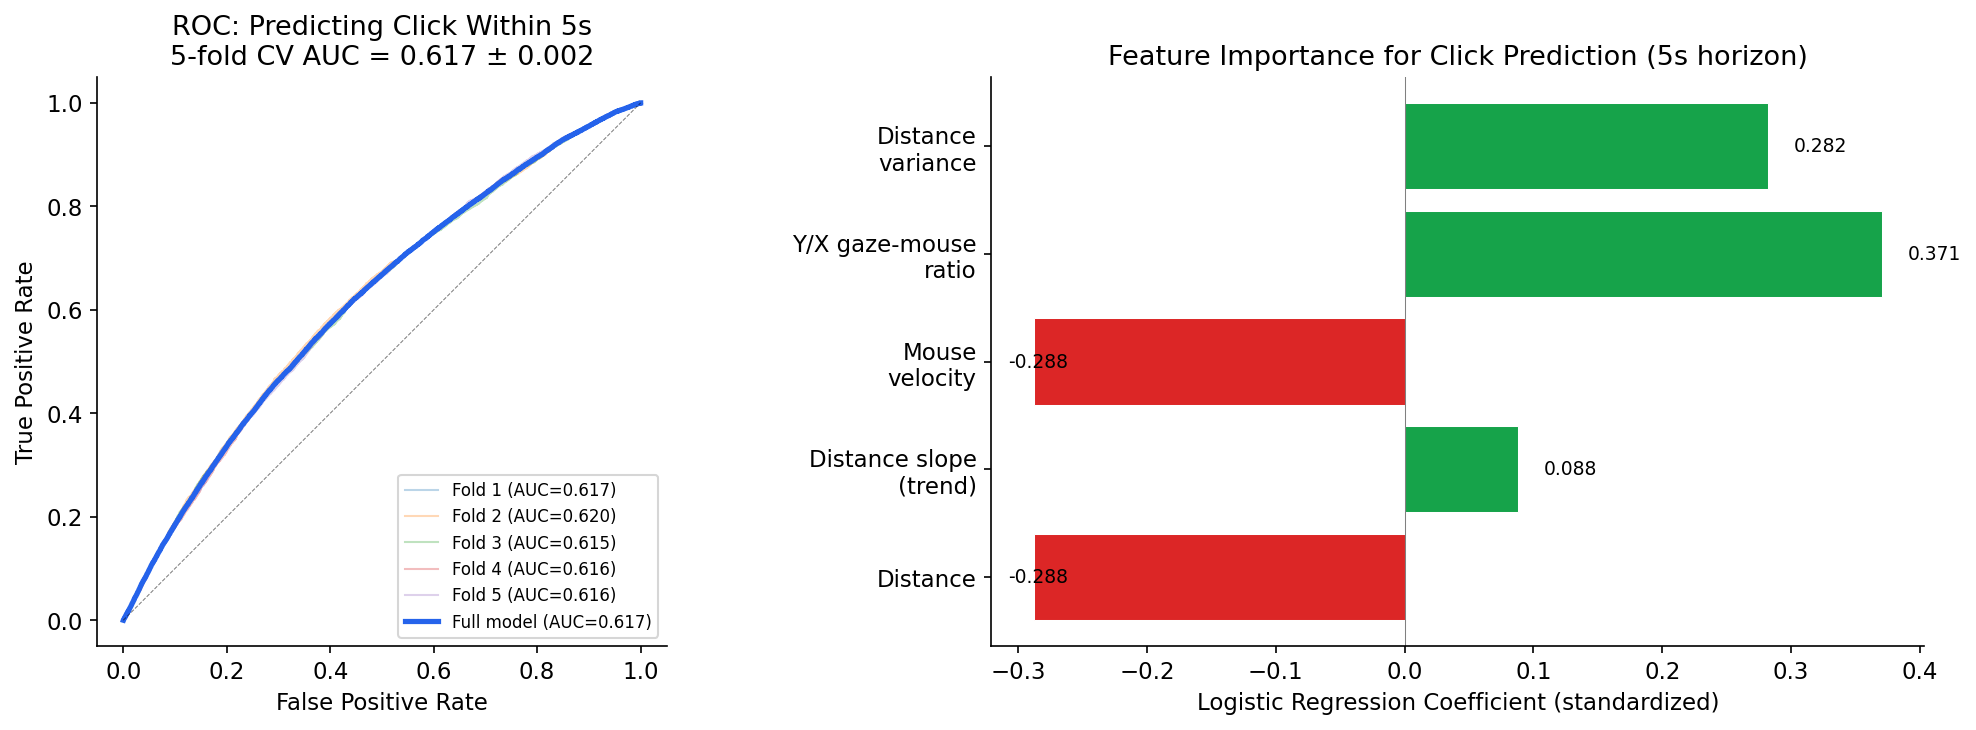


All-features model: AUC = 0.617 ± 0.002 (5-fold CV)

Coefficients (standardized):
  distance            : -0.2876  ← predicts click
  dist_slope          : +0.0880  → predicts no-click
  mouse_velocity      : -0.2879  ← predicts click
  xy_ratio            : +0.3707  → predicts no-click
  dist_variance       : +0.2818  → predicts no-click


In [12]:
# --- Plot 7: ROC Curve with 5-fold stratified CV ---

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Stratified 5-fold CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
all_fpr = []
all_tpr = []
aucs = []

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for fold, (train_idx, test_idx) in enumerate(cv.split(X_scaled, y)):
    X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    clf = LogisticRegression(max_iter=1000, random_state=42)
    clf.fit(X_train, y_train)
    
    y_prob = clf.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    fold_auc = auc(fpr, tpr)
    aucs.append(fold_auc)
    
    ax1.plot(fpr, tpr, alpha=0.3, linewidth=1, label=f'Fold {fold+1} (AUC={fold_auc:.3f})')

# Train final model on all data for coefficients
clf_final = LogisticRegression(max_iter=1000, random_state=42)
clf_final.fit(X_scaled, y)
y_prob_final = clf_final.predict_proba(X_scaled)[:, 1]
fpr_final, tpr_final, _ = roc_curve(y, y_prob_final)
auc_final = auc(fpr_final, tpr_final)

ax1.plot(fpr_final, tpr_final, color='#2563eb', linewidth=2.5, label=f'Full model (AUC={auc_final:.3f})')
ax1.plot([0, 1], [0, 1], 'k--', linewidth=0.5, alpha=0.5)
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title(f'ROC: Predicting Click Within 5s\n5-fold CV AUC = {np.mean(aucs):.3f} ± {np.std(aucs):.3f}')
ax1.legend(fontsize=8, loc='lower right')
ax1.set_aspect('equal')

# --- Plot 8: Feature importance (logistic regression coefficients) ---
coefs = clf_final.coef_[0]
feature_labels = ['Distance', 'Distance slope\n(trend)', 'Mouse\nvelocity', 'Y/X gaze-mouse\nratio', 'Distance\nvariance']
colors = ['#dc2626' if c < 0 else '#16a34a' for c in coefs]

bars = ax2.barh(range(len(coefs)), coefs, color=colors, edgecolor='white', linewidth=0.5)
ax2.set_yticks(range(len(coefs)))
ax2.set_yticklabels(feature_labels)
ax2.set_xlabel('Logistic Regression Coefficient (standardized)')
ax2.set_title('Feature Importance for Click Prediction (5s horizon)')
ax2.axvline(0, color='gray', linewidth=0.5)

# Annotate with values
for i, (bar, c) in enumerate(zip(bars, coefs)):
    ax2.text(c + 0.02 * np.sign(c), i, f'{c:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('plot7_roc_and_features.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"\nAll-features model: AUC = {np.mean(aucs):.3f} ± {np.std(aucs):.3f} (5-fold CV)")
print(f"\nCoefficients (standardized):")
for name, c in zip(feature_names, coefs):
    direction = "← predicts click" if c < 0 else "→ predicts no-click"
    # For distance: negative = lower distance predicts click (correct)
    # For slope: negative = declining slope predicts click (correct)
    print(f"  {name:20s}: {c:+.4f}  {direction}")

Horizon  1s: AUC = 0.678 ± 0.015  (positive rate: 1.2%)


Horizon  2s: AUC = 0.682 ± 0.005  (positive rate: 6.0%)


Horizon  3s: AUC = 0.650 ± 0.005  (positive rate: 12.1%)
Horizon  5s: AUC = 0.617 ± 0.002  (positive rate: 23.1%)


Horizon  7s: AUC = 0.601 ± 0.002  (positive rate: 32.7%)


Horizon 10s: AUC = 0.585 ± 0.004  (positive rate: 45.1%)


Horizon 15s: AUC = 0.601 ± 0.004  (positive rate: 61.8%)


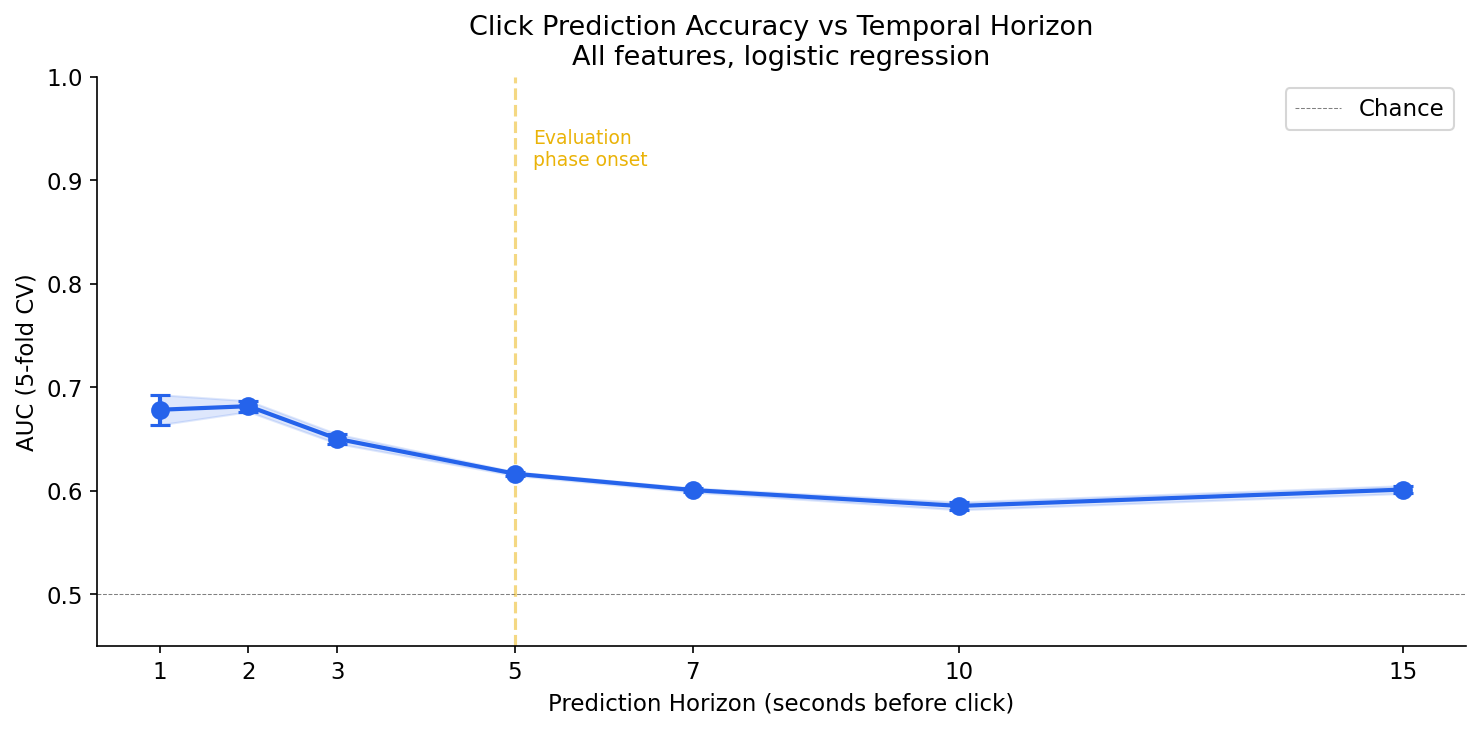

In [13]:
# --- Plot 8: AUC vs Prediction Horizon ---
# How far in advance can we predict? Test horizons from 1s to 15s.

horizons = [1, 2, 3, 5, 7, 10, 15]
horizon_aucs = {}

for h in horizons:
    # Relabel: click within h seconds
    y_h = (ttc_arr <= h).astype(int)
    
    # Skip if too few positives or negatives
    if np.sum(y_h) < 50 or np.sum(y_h == 0) < 50:
        continue
    
    # 5-fold CV
    cv_aucs = []
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    for train_idx, test_idx in cv.split(X_scaled, y_h):
        clf = LogisticRegression(max_iter=1000, random_state=42)
        clf.fit(X_scaled[train_idx], y_h[train_idx])
        y_prob = clf.predict_proba(X_scaled[test_idx])[:, 1]
        cv_aucs.append(roc_auc_score(y_h[test_idx], y_prob))
    
    horizon_aucs[h] = (np.mean(cv_aucs), np.std(cv_aucs))
    pct_pos = 100 * np.mean(y_h)
    print(f"Horizon {h:2d}s: AUC = {np.mean(cv_aucs):.3f} ± {np.std(cv_aucs):.3f}  (positive rate: {pct_pos:.1f}%)")

fig, ax = plt.subplots(figsize=(10, 5))

hs = sorted(horizon_aucs.keys())
means = [horizon_aucs[h][0] for h in hs]
stds = [horizon_aucs[h][1] for h in hs]

ax.errorbar(hs, means, yerr=stds, marker='o', markersize=8, linewidth=2, color='#2563eb',
            capsize=5, capthick=1.5)
ax.fill_between(hs, [m - s for m, s in zip(means, stds)], [m + s for m, s in zip(means, stds)],
                alpha=0.15, color='#2563eb')

ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=0.5, label='Chance')
ax.set_xlabel('Prediction Horizon (seconds before click)')
ax.set_ylabel('AUC (5-fold CV)')
ax.set_title('Click Prediction Accuracy vs Temporal Horizon\nAll features, logistic regression')
ax.set_ylim(0.45, 1.0)
ax.set_xticks(hs)
ax.legend()

# Annotate the 5s evaluation-phase boundary
ax.axvline(x=5, color='#eab308', linestyle='--', alpha=0.5)
ax.text(5.2, 0.95, 'Evaluation\nphase onset', fontsize=9, color='#eab308', va='top')

plt.tight_layout()
plt.savefig('plot8_auc_vs_horizon.png', dpi=200, bbox_inches='tight')
plt.show()

## The Critical Comparison: Does Convergence *Rate* Add Predictive Power?

Three models, same 5-fold CV, 5s horizon:
1. **Distance only** — raw mouse-gaze distance (what most papers measure)
2. **Distance + trend** — adds the slope/rate of convergence (the evaluation phase signal)
3. **All features** — distance, trend, mouse velocity, XY ratio, distance variance

If model 2 substantially beats model 1, the convergence *rate* carries information about click intent beyond what raw proximity provides. This is the evaluation phase doing work.

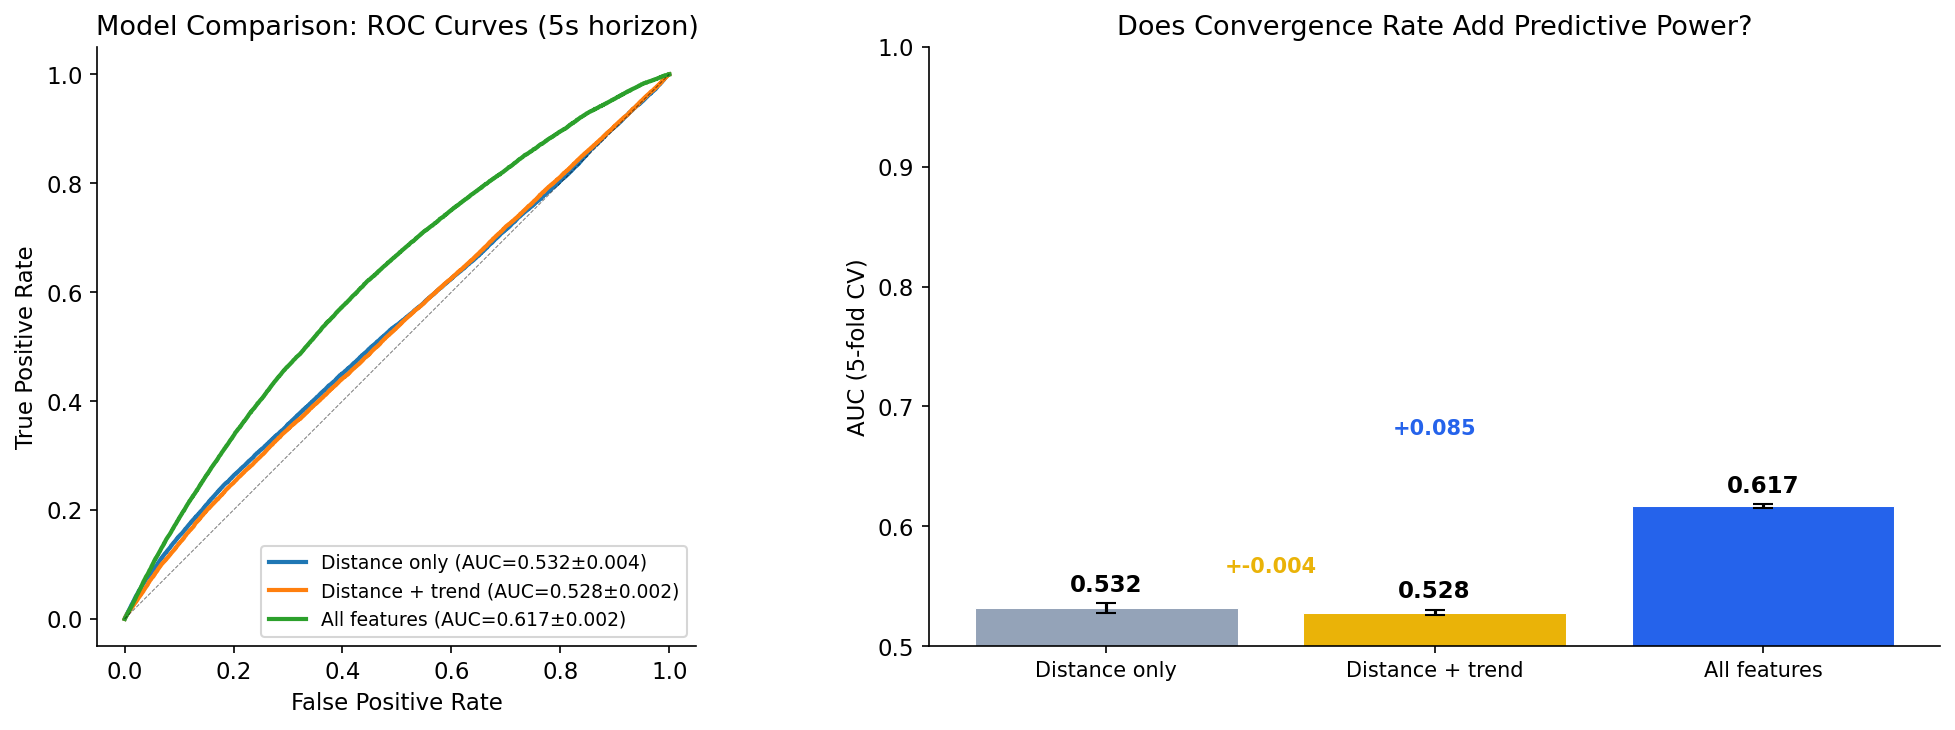


CRITICAL COMPARISON: Does convergence rate predict clicks?
  Distance only            : AUC = 0.532 ± 0.004
  Distance + trend         : AUC = 0.528 ± 0.002
  All features             : AUC = 0.617 ± 0.002

  Distance → Distance+trend: Δ AUC = -0.004
  Distance → All features:   Δ AUC = +0.085
  Distance+trend → All:      Δ AUC = +0.089

  ✗ The convergence rate adds minimal predictive power (-0.004 AUC).
    Raw distance already captures most of the click-intent signal.


In [14]:
# --- Plot 9: Critical comparison — distance-only vs distance+trend vs all features ---

# Define feature subsets
feature_subsets = {
    'Distance only': [0],              # just distance
    'Distance + trend': [0, 1],        # distance + dist_slope
    'All features': list(range(5)),    # all 5 features
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

comparison_results = {}

for name, feat_idx in feature_subsets.items():
    X_sub = X_scaled[:, feat_idx]
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_aucs = []
    
    # Collect ROC for plotting (use all data for the curve, CV for the number)
    for train_idx, test_idx in cv.split(X_sub, y):
        clf = LogisticRegression(max_iter=1000, random_state=42)
        clf.fit(X_sub[train_idx], y[train_idx])
        y_prob = clf.predict_proba(X_sub[test_idx])[:, 1]
        cv_aucs.append(roc_auc_score(y[test_idx], y_prob))
    
    # Full model for ROC curve
    clf = LogisticRegression(max_iter=1000, random_state=42)
    clf.fit(X_sub, y)
    y_prob = clf.predict_proba(X_sub)[:, 1]
    fpr, tpr, _ = roc_curve(y, y_prob)
    
    mean_auc = np.mean(cv_aucs)
    std_auc = np.std(cv_aucs)
    comparison_results[name] = (mean_auc, std_auc)
    
    ax1.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC={mean_auc:.3f}±{std_auc:.3f})')

ax1.plot([0, 1], [0, 1], 'k--', linewidth=0.5, alpha=0.5)
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('Model Comparison: ROC Curves (5s horizon)')
ax1.legend(fontsize=9, loc='lower right')
ax1.set_aspect('equal')

# Bar chart comparison
names = list(comparison_results.keys())
means = [comparison_results[n][0] for n in names]
stds = [comparison_results[n][1] for n in names]
colors = ['#94a3b8', '#eab308', '#2563eb']

bars = ax2.bar(range(len(names)), means, yerr=stds, color=colors, edgecolor='white',
               linewidth=0.5, capsize=5)
ax2.set_xticks(range(len(names)))
ax2.set_xticklabels(names, fontsize=10)
ax2.set_ylabel('AUC (5-fold CV)')
ax2.set_title('Does Convergence Rate Add Predictive Power?')
ax2.set_ylim(0.5, 1.0)
ax2.axhline(y=0.5, color='gray', linestyle='--', linewidth=0.5)

# Annotate bars
for i, (m, s) in enumerate(zip(means, stds)):
    ax2.text(i, m + s + 0.01, f'{m:.3f}', ha='center', fontsize=11, fontweight='bold')

# Delta annotations
if len(means) >= 2:
    delta_trend = means[1] - means[0]
    ax2.annotate(f'+{delta_trend:.3f}', xy=(0.5, max(means[0], means[1]) + 0.03),
                fontsize=10, ha='center', color='#eab308', fontweight='bold')
if len(means) >= 3:
    delta_all = means[2] - means[0]
    ax2.annotate(f'+{delta_all:.3f}', xy=(1.0, max(means[0], means[2]) + 0.06),
                fontsize=10, ha='center', color='#2563eb', fontweight='bold')

plt.tight_layout()
plt.savefig('plot9_model_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

# --- Summary statistics ---
print("\n" + "="*60)
print("CRITICAL COMPARISON: Does convergence rate predict clicks?")
print("="*60)
for name in names:
    m, s = comparison_results[name]
    print(f"  {name:25s}: AUC = {m:.3f} ± {s:.3f}")

d_only = comparison_results['Distance only'][0]
d_trend = comparison_results['Distance + trend'][0]
d_all = comparison_results['All features'][0]

print(f"\n  Distance → Distance+trend: Δ AUC = {d_trend - d_only:+.3f}")
print(f"  Distance → All features:   Δ AUC = {d_all - d_only:+.3f}")
print(f"  Distance+trend → All:      Δ AUC = {d_all - d_trend:+.3f}")

if d_trend - d_only > 0.01:
    print(f"\n  ✓ The convergence RATE adds {d_trend - d_only:.3f} AUC beyond raw distance.")
    print(f"    The evaluation phase signal (declining distance over time) carries")
    print(f"    predictive information about click intent that proximity alone misses.")
else:
    print(f"\n  ✗ The convergence rate adds minimal predictive power ({d_trend - d_only:+.3f} AUC).")
    print(f"    Raw distance already captures most of the click-intent signal.")

## Plot 10: Scroll dynamics and click prediction

The 5s inflection in the convergence curve may be a scroll artifact. On a SERP, the user scrolls to bring results into the viewport. When the scroll stops with the target visible, that's a strong click predictor.

**Key question:** Is the convergence we see actually "scroll locks viewport → gaze evaluates → mouse approaches → click"? If so, the scroll-stop event is the real signal, and our gaze-mouse distance is downstream of viewport position.

Features to test:
- Scroll velocity at each fixation (active scrolling vs. viewport locked)
- Time since last scroll event
- Whether the viewport is "settled" (no scroll for N ms)
- Scroll position relative to final click Y (how far is the target from viewport center?)

In [15]:
# Reprocess trials with scroll data — now using scroll-corrected coords from cell above
# (load_mouse_and_scroll and get_scroll_at are already defined)

def time_since_last_scroll(t, scroll_events):
    """Ms since last scroll event. Large = viewport settled."""
    if not scroll_events:
        return 99999
    last = 0
    for st, _ in scroll_events:
        if st <= t:
            last = st
        else:
            break
    return t - last if last > 0 else 99999

def scroll_velocity_at(t, scroll_events, window_ms=500):
    """Scroll speed (px/s) in a window around time t."""
    nearby = [(st, sy) for st, sy in scroll_events if abs(st - t) < window_ms]
    if len(nearby) < 2:
        return 0.0
    dt = (nearby[-1][0] - nearby[0][0]) / 1000.0
    if dt < 0.01:
        return 0.0
    dy = abs(nearby[-1][1] - nearby[0][1])
    return dy / dt

def process_trial_with_scroll(tid):
    """Returns list of dicts with scroll-enriched features per fixation."""
    meta = load_metadata(tid)
    fixes = load_fixations(tid)
    moves, click_t, scrolls = load_mouse_and_scroll(tid, meta)
    
    if click_t is None or len(fixes) < 3 or len(moves) < 3:
        return None
    
    # Get click position — convert to page-space
    # Coordinate-safe: evtrack ypos is ALREADY page-space. Do NOT add scroll.
    click_y_page = None
    with open(os.path.join(MOUSE_DIR, f'{tid}.csv')) as f:
        for r in csv.DictReader(f):
            if r['event'] == 'click':
                click_y_page = float(r['ypos'])
                break
    
    click_page_y = click_y_page
    
    results = []
    for ft, fx, fy, fd in fixes:
        ttc = click_t - ft
        if ttc < 0:
            continue
        
        m = nearest_mouse(ft, moves)
        if m is None:
            continue
        mx_screen, my_screen, mt = m
        
        # Page-space mouse position
        scroll_at_fix = get_scroll_at(mt, scrolls)
        mx_page = mx_screen
        my_page = my_screen + scroll_at_fix
        
        # Page-space distance (corrected)
        dist_page = math.sqrt((fx - mx_page)**2 + (fy - my_page)**2)
        
        # Scroll features
        time_since_scroll = time_since_last_scroll(ft, scrolls)
        scroll_vel = scroll_velocity_at(ft, scrolls)
        viewport_settled = 1 if time_since_scroll > 1000 else 0
        
        # Viewport presence — target in viewport?
        viewport_top = scroll_at_fix
        viewport_bottom = scroll_at_fix + 1024
        target_in_viewport = 1 if (click_page_y and 
                                    viewport_top <= click_page_y <= viewport_bottom) else 0
        
        results.append({
            'trial': tid,
            'ttc_s': ttc / 1000.0,
            'dist_screen': dist_page,  # now page-space corrected
            'scroll_offset': scroll_at_fix,
            'time_since_scroll_ms': time_since_scroll,
            'scroll_velocity': scroll_vel,
            'viewport_settled': viewport_settled,
            'target_in_viewport': target_in_viewport,
            'target_viewport_dist': abs(click_page_y - (scroll_at_fix + 512)) if click_page_y else None,
        })
    
    return results if results else None

# Process all trials
print("Processing trials with scroll-corrected coordinates...")
scroll_points = []
processed = 0
for i, tid in enumerate(trial_ids):
    if (i + 1) % 500 == 0:
        print(f"  {i+1}/{len(trial_ids)}...")
    try:
        pts = process_trial_with_scroll(tid)
        if pts:
            processed += 1
            scroll_points.extend(pts)
    except:
        pass

print(f"Processed {processed} trials, {len(scroll_points)} scroll-enriched fixation points")
print(f"Trials with any scroll: {len(set(p['trial'] for p in scroll_points if p['scroll_offset'] > 0))}")
print(f"Fixations with target in viewport: {sum(1 for p in scroll_points if p['target_in_viewport'])}")

Processing trials with scroll-corrected coordinates...


  500/2776...


  1000/2776...


  1500/2776...


  2000/2776...


  2500/2776...


Processed 2762 trials, 128887 scroll-enriched fixation points
Trials with any scroll: 2234
Fixations with target in viewport: 75225


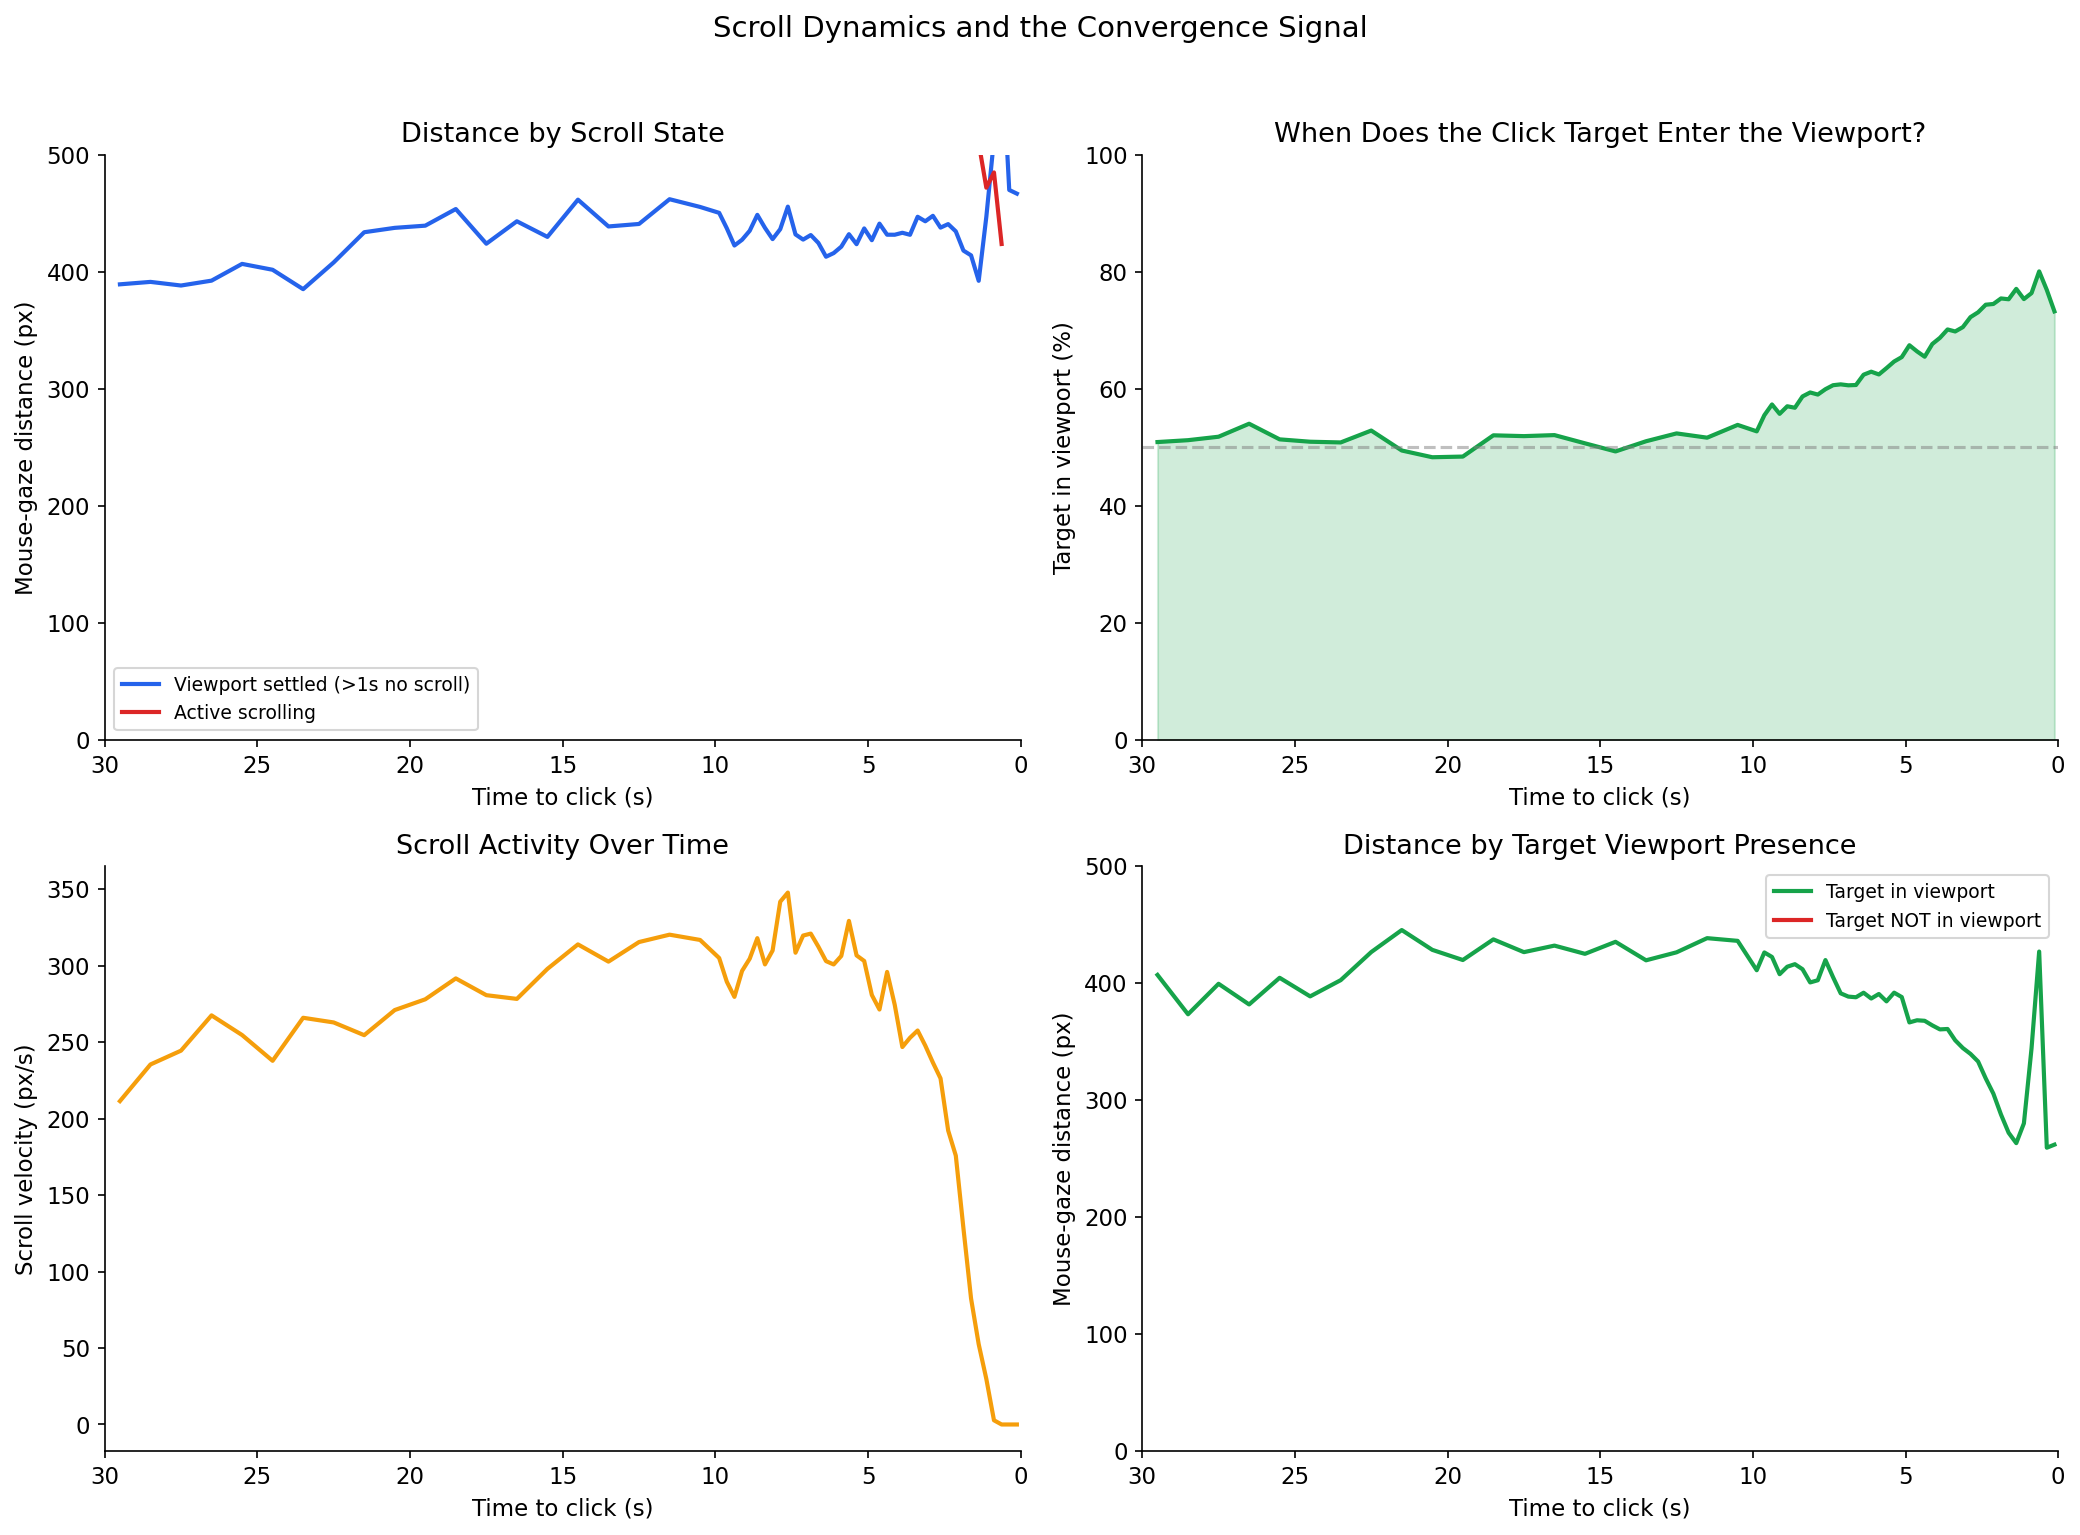

Fixations during settled viewport: 85733 (66.5%)
Fixations during active scroll: 43154 (33.5%)

Target in viewport at 5s before click: 66.0%
Target in viewport at 2s before click: 74.9%
Target in viewport at 10s before click: 53.9%


In [16]:
# Plot 10a: Convergence curve split by scroll state
sp_ttc = np.array([p['ttc_s'] for p in scroll_points])
sp_dist = np.array([p['dist_screen'] for p in scroll_points])
sp_settled = np.array([p['viewport_settled'] for p in scroll_points])
sp_in_viewport = np.array([p['target_in_viewport'] for p in scroll_points])
sp_scroll_vel = np.array([p['scroll_velocity'] for p in scroll_points])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 10a: Distance split by viewport settled vs active scroll
ax = axes[0, 0]
for mask, label, color in [
    (sp_settled == 1, 'Viewport settled (>1s no scroll)', '#2563eb'),
    (sp_settled == 0, 'Active scrolling', '#dc2626'),
]:
    means = []
    for i in range(len(bin_edges) - 1):
        m = (sp_ttc >= bin_edges[i]) & (sp_ttc < bin_edges[i+1]) & mask
        vals = sp_dist[m]
        means.append(np.mean(vals) if len(vals) >= 10 else np.nan)
    means = np.array(means)
    v = ~np.isnan(means)
    ax.plot(bin_centers[v], means[v], color=color, linewidth=2, label=label)

ax.set_xlabel('Time to click (s)')
ax.set_ylabel('Mouse-gaze distance (px)')
ax.set_title('Distance by Scroll State')
ax.set_xlim(0, 30)
ax.set_ylim(0, 500)
ax.invert_xaxis()
ax.legend(fontsize=9)

# 10b: Target-in-viewport rate by time-to-click
ax = axes[0, 1]
viewport_rates = []
for i in range(len(bin_edges) - 1):
    m = (sp_ttc >= bin_edges[i]) & (sp_ttc < bin_edges[i+1])
    if np.sum(m) >= 10:
        viewport_rates.append(np.mean(sp_in_viewport[m]))
    else:
        viewport_rates.append(np.nan)
viewport_rates = np.array(viewport_rates)
v = ~np.isnan(viewport_rates)
ax.plot(bin_centers[v], viewport_rates[v] * 100, color='#16a34a', linewidth=2)
ax.fill_between(bin_centers[v], 0, viewport_rates[v] * 100, alpha=0.2, color='#16a34a')
ax.set_xlabel('Time to click (s)')
ax.set_ylabel('Target in viewport (%)')
ax.set_title('When Does the Click Target Enter the Viewport?')
ax.set_xlim(0, 30)
ax.set_ylim(0, 100)
ax.invert_xaxis()
ax.axhline(y=50, color='gray', linestyle='--', alpha=0.5)

# 10c: Scroll velocity by time-to-click
ax = axes[1, 0]
vel_means = []
for i in range(len(bin_edges) - 1):
    m = (sp_ttc >= bin_edges[i]) & (sp_ttc < bin_edges[i+1])
    vals = sp_scroll_vel[m]
    vel_means.append(np.mean(vals) if len(vals) >= 10 else np.nan)
vel_means = np.array(vel_means)
v = ~np.isnan(vel_means)
ax.plot(bin_centers[v], vel_means[v], color='#f59e0b', linewidth=2)
ax.set_xlabel('Time to click (s)')
ax.set_ylabel('Scroll velocity (px/s)')
ax.set_title('Scroll Activity Over Time')
ax.set_xlim(0, 30)
ax.invert_xaxis()

# 10d: Distance conditioned on target-in-viewport
ax = axes[1, 1]
for mask, label, color in [
    (sp_in_viewport == 1, 'Target in viewport', '#16a34a'),
    (sp_in_viewport == 0, 'Target NOT in viewport', '#dc2626'),
]:
    means = []
    for i in range(len(bin_edges) - 1):
        m = (sp_ttc >= bin_edges[i]) & (sp_ttc < bin_edges[i+1]) & mask
        vals = sp_dist[m]
        means.append(np.mean(vals) if len(vals) >= 10 else np.nan)
    means = np.array(means)
    v = ~np.isnan(means)
    ax.plot(bin_centers[v], means[v], color=color, linewidth=2, label=label)

ax.set_xlabel('Time to click (s)')
ax.set_ylabel('Mouse-gaze distance (px)')
ax.set_title('Distance by Target Viewport Presence')
ax.set_xlim(0, 30)
ax.set_ylim(0, 500)
ax.invert_xaxis()
ax.legend(fontsize=9)

plt.suptitle('Scroll Dynamics and the Convergence Signal', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('plot10_scroll_dynamics.png', dpi=200, bbox_inches='tight')
plt.show()

# Key stats
settled_mask = sp_settled == 1
scrolling_mask = sp_settled == 0
print(f"Fixations during settled viewport: {np.sum(settled_mask)} ({np.mean(settled_mask)*100:.1f}%)")
print(f"Fixations during active scroll: {np.sum(scrolling_mask)} ({np.mean(scrolling_mask)*100:.1f}%)")
print(f"\nTarget in viewport at 5s before click: {np.mean(sp_in_viewport[(sp_ttc >= 4.5) & (sp_ttc < 5.5)])*100:.1f}%")
print(f"Target in viewport at 2s before click: {np.mean(sp_in_viewport[(sp_ttc >= 1.5) & (sp_ttc < 2.5)])*100:.1f}%")
print(f"Target in viewport at 10s before click: {np.mean(sp_in_viewport[(sp_ttc >= 9.5) & (sp_ttc < 10.5)])*100:.1f}%")

## Plot 11: Updated prediction with scroll features

Does adding viewport state to the logistic regression improve click prediction? The critical test: if scroll features explain most of the convergence signal, they should substantially boost AUC over distance-only.

Scroll-enriched dataset: 128702 samples, 23.1% positive

Model                                   AUC
--------------------------------------------
Distance only                  0.531 ± 0.036


Distance + trend (prev)        0.531 ± 0.036


Scroll features only           0.687 ± 0.033
Distance + scroll              0.687 ± 0.033

Full model coefficients (standardized):
  distance                 : -0.0100  ← predicts click
  viewport_settled         : +0.4107  → predicts no-click
  target_in_viewport       : +0.3794  → predicts no-click
  scroll_velocity          : -0.1233  ← predicts click
  time_since_scroll_s      : -0.6907  ← predicts click


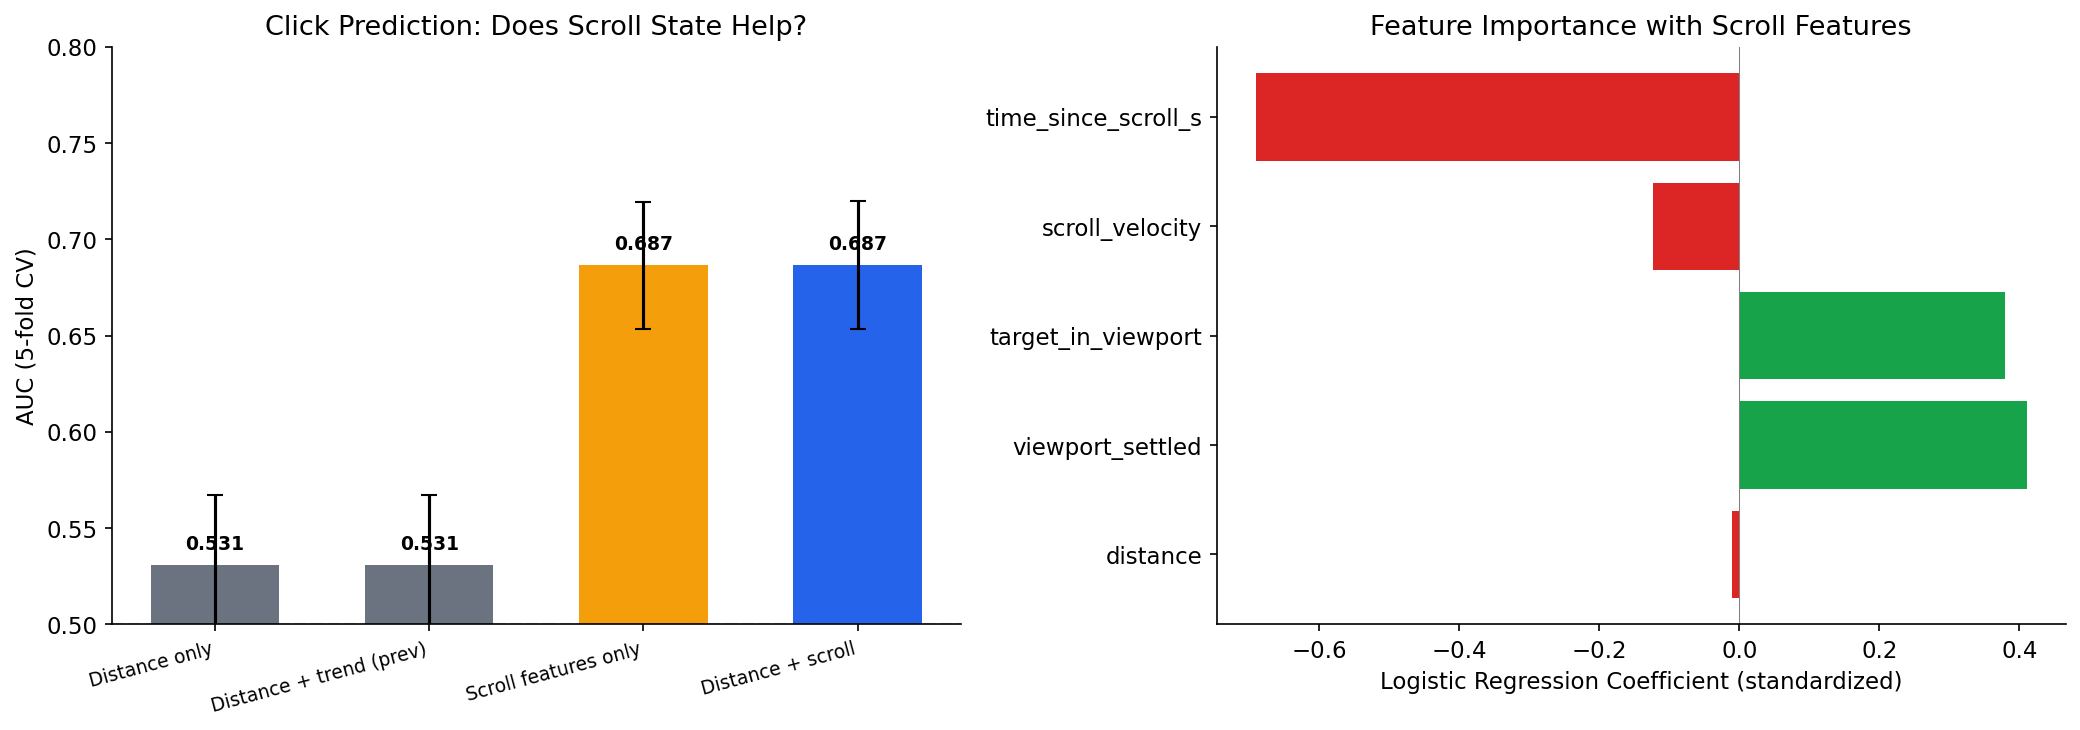


Scroll features alone: AUC = 0.687
Distance + scroll vs distance only: Δ AUC = +0.156
Scroll features substantially improve prediction!


In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

# Build feature matrix from scroll-enriched data
horizon = 5.0  # seconds

# Features per fixation
feat_names_scroll = ['distance', 'viewport_settled', 'target_in_viewport', 
                     'scroll_velocity', 'time_since_scroll_s']

X_rows = []
y_rows = []

for p in scroll_points:
    ttc = p['ttc_s']
    if ttc > 60:  # skip very long trials
        continue
    
    label = 1 if ttc <= horizon else 0
    
    X_rows.append([
        p['dist_screen'],
        p['viewport_settled'],
        p['target_in_viewport'],
        p['scroll_velocity'],
        min(p['time_since_scroll_ms'] / 1000.0, 30),  # cap at 30s
    ])
    y_rows.append(label)

X_scroll = np.array(X_rows)
y_scroll = np.array(y_rows)

print(f"Scroll-enriched dataset: {len(y_scroll)} samples, {np.mean(y_scroll)*100:.1f}% positive")

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_scroll)

# Model comparison
models = {
    'Distance only': [0],  # just distance
    'Distance + trend (prev)': [0],  # same as before, single feature
    'Scroll features only': [1, 2, 3, 4],  # viewport_settled, target_in_viewport, scroll_vel, time_since
    'Distance + scroll': [0, 1, 2, 3, 4],  # all
}

print(f"\n{'Model':<30} {'AUC':>12}")
print("-" * 44)
results_scroll = {}
for name, cols in models.items():
    X_sub = X_scaled[:, cols]
    clf = LogisticRegression(max_iter=1000, random_state=42)
    scores = cross_val_score(clf, X_sub, y_scroll, cv=5, scoring='roc_auc')
    results_scroll[name] = (np.mean(scores), np.std(scores))
    print(f"{name:<30} {np.mean(scores):.3f} ± {np.std(scores):.3f}")

# Fit full model for coefficients
clf_full = LogisticRegression(max_iter=1000, random_state=42)
clf_full.fit(X_scaled, y_scroll)

print(f"\nFull model coefficients (standardized):")
for name, coef in zip(feat_names_scroll, clf_full.coef_[0]):
    direction = "← predicts click" if coef < 0 else "→ predicts no-click"
    print(f"  {name:<25}: {coef:+.4f}  {direction}")

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of AUC comparison
names = list(results_scroll.keys())
aucs = [results_scroll[n][0] for n in names]
stds = [results_scroll[n][1] for n in names]
colors = ['#6b7280', '#6b7280', '#f59e0b', '#2563eb']
bars = ax1.bar(range(len(names)), aucs, yerr=stds, color=colors, capsize=4, width=0.6)
ax1.set_xticks(range(len(names)))
ax1.set_xticklabels(names, rotation=15, ha='right', fontsize=9)
ax1.set_ylabel('AUC (5-fold CV)')
ax1.set_title('Click Prediction: Does Scroll State Help?')
ax1.set_ylim(0.5, 0.8)
ax1.axhline(y=0.5, color='gray', linestyle='--', alpha=0.3, label='Chance')
for bar, auc in zip(bars, aucs):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008, 
             f'{auc:.3f}', ha='center', fontsize=9, fontweight='bold')

# Coefficient plot
coefs = clf_full.coef_[0]
colors_coef = ['#dc2626' if c < 0 else '#16a34a' for c in coefs]
ax2.barh(feat_names_scroll, coefs, color=colors_coef)
ax2.set_xlabel('Logistic Regression Coefficient (standardized)')
ax2.set_title('Feature Importance with Scroll Features')
ax2.axvline(0, color='gray', linewidth=0.5)

plt.tight_layout()
plt.savefig('plot11_scroll_prediction.png', dpi=200, bbox_inches='tight')
plt.show()

delta = results_scroll['Distance + scroll'][0] - results_scroll['Distance only'][0]
scroll_only = results_scroll['Scroll features only'][0]
print(f"\nScroll features alone: AUC = {scroll_only:.3f}")
print(f"Distance + scroll vs distance only: Δ AUC = +{delta:.3f}")
print(f"{'Scroll features substantially improve prediction!' if delta > 0.02 else 'Scroll features add modest improvement.'}")